# Week 3 — Information Timing, Technical Indicators, Features, and Signals

[Open this notebook in Google Colab](https://colab.research.google.com/github/KennethWYLee/FinTech/blob/main/course/week3_main.ipynb)

The course repository is public. If the direct Colab link is temporarily unavailable, download `week3_main.ipynb` from GitHub and upload the file to Colab.

This is the complete Week 3 lesson. It integrates preparation, input availability, technical indicators, financially motivated features, leakage checks, publication-time alignment, executable examples, discussion questions, independent practice, troubleshooting, extensions, and sources in one document.

## Core financial question

How can a financial idea be converted into a feature and then a signal while using only information that was available at the stated decision time?

Week 2 established auditable prices, returns, dates, fields, and units. Week 3 adds information availability, technical indicators, features, and signals. Week 4 will convert the signal into a position, trade, return, and wealth ledger. Week 3 deliberately stops before that accounting: it does not report strategy returns, costs, performance measures, or profitability.

Each issue first uses controlled artificial data and then a source-grounded example. Most second examples request fixed historical AAPL rows through yfinance; Issues 17 and 18 use dated SEC and ALFRED release records. The notebook preserves only request summaries, derived features, checks, and figures rather than downloaded Yahoo Finance rows. Neither type of example establishes predictability or recommends a trade.


## Observable outcome

After completing Week 3, you will produce a reproducible notebook that states a financial hypothesis, documents the information time of every input, calculates trailing technical indicators and features, rejects deliberately invalid candidates, aligns separately published data by publication time, and creates a simple signal without treating it as an executed position.

## Learning objectives

After completing Week 3, you should be able to:

- distinguish observation, publication, signal, decision, execution, and evaluation times;
- translate a financial hypothesis into a measurable feature with a stated lookback, unit, first valid date, and contradiction condition;
- calculate and interpret simple moving averages, exponentially weighted means, moving-average gaps, trailing momentum, rolling volatility, range, and volume-change features;
- identify future values, negative shifts, centered windows, full-sample preprocessing, and historical revisions that can introduce unavailable information;
- align separately published variables to decision times using only releases already available; and
- convert a stated feature rule into a signal while preserving missing history and postponing performance claims.

## Before you begin

Complete Week 2 or be able to calculate returns from a positive, sorted, unique price series. Use Google Colab or a local Jupyter environment with Python, `numpy`, `pandas`, `matplotlib`, and `yfinance`. The controlled examples work from embedded values; the source-grounded AAPL examples require an internet connection when they are executed.

Each issue uses cells with one primary teaching purpose. The sequence is: read the financial problem and any useful formula; record a checkable prediction; run the controlled example; interpret its preserved output; inspect the source-grounded setup and record a second prediction; run and interpret that example; and answer two questions grounded in the displayed evidence. Keep the original prediction visible and add a revision only when the output differs. Common troubleshooting and completion guidance appear once near the end of the notebook.


# Navigation through the eighteen issues

The eighteen issues form six connected sections. Each issue answers one core question, and every cell has one primary instructional purpose. An actual feature workflow must preserve every earlier information and data decision.

| Section | Issues | Main question | Evidence carried forward |
|---|---:|---|---|
| Information boundaries and input readiness | 1–5 | When is each value usable, what claim is examined, and are the inputs ready? | Ordered times, recorded source facts, financial question, window requirements, and input checks |
| Technical indicators and features | 6–12 | What does each trailing calculation measure, and which inputs, units, and first valid dates does it require? | Moving averages, moving-average gap, momentum, volatility, price range, and Volume change |
| Target alignment | 13 | How can a later outcome be stored for learning without entering the time-$t$ feature set? | Explicit feature and target roles with source endpoints |
| Leakage checks | 14–15 | Do rolling calculations or preprocessing parameters depend on later rows? | Prefix test and development-only preprocessing parameters |
| Signal construction | 16 | How does a stated rule handle valid values and unavailable feature history? | Signal output that keeps unavailable history missing and is not yet a position |
| Separately published and revised data | 17–18 | Which release and release version were available for each historical decision? | Backward publication-time alignment and release-specific values |

Apply the dependency in this order:

```text
documented financial data and return intervals
        ↓
observation and publication availability
        ↓
financial question and trailing feature
        ↓
target and leakage audit
        ↓
signal with a stated decision boundary
        ↓
Week 4 position and backtest ledger
```

A later model or backtest cannot repair an earlier timing error. If a source value, release time, lookback, or missing-history rule remains unresolved, return to that decision before interpreting the signal.


# Preparation and required records

## Working rules

- Treat values explicitly labeled artificial as controlled teaching data. Treat the AAPL, SEC, and ALFRED examples only as source-grounded observations under their cited request or release record.
- A feature may use only values available by its stated signal time.
- A target may describe a later outcome, but it must never be included among the time-$t$ features.
- Missing feature history remains missing until the required source observations exist; it is not automatically a zero signal.
- An indicator or signal is a calculated object, not evidence of a fill, return, profit, or future performance.
- The AAPL request is a lesson example, not the common Report 1 dataset. Report 1 data, periods, costs, constraints, and evaluation settings remain pending until the instructor publishes them.

## Information to record for each feature

Complete this record once for each feature retained in the integrated case. Do not repeat it after every worked example.

```text
Feature and financial question:
Source field and period represented:
Formula, lookback, unit, and first valid date:
Latest included observation and when it became available:
Feature and signal calculation time:
Decision time and earliest permitted execution:
Target horizon and when that target becomes observable:
Missing-history or revision rule:
One leakage check performed:
One conclusion this record cannot support:
```

## Required checks

Preserve the relevant results rather than writing only that a check passed:

- input dates are parsed, unique, and sorted;
- prices used in ratios are finite and positive;
- every rolling calculation states its source column, lookback, endpoint, `min_periods`, and first valid date;
- feature units and scale are recorded;
- negative shifts, centered windows, future targets, and full-sample preprocessing are excluded from time-$t$ features;
- publication-time joins are sorted and never match a release later than the decision;
- initial unavailable features and signals remain missing under the stated rule; and
- no signal is described as a position or assigned a return in Week 3.


In [1]:
# Purpose: load the shared packages, fixed request, and environment record used throughout Week 3.
from importlib.metadata import PackageNotFoundError, version
import platform

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    import yfinance as yf
    YFINANCE_VERSION = version("yfinance")
except (ImportError, PackageNotFoundError):
    yf = None
    YFINANCE_VERSION = "not installed"

pd.set_option("display.max_columns", 24)
pd.set_option("display.width", 140)
plt.rcParams.update(
    {
        "figure.figsize": (7.6, 3.8),
        "figure.dpi": 110,
        "axes.grid": True,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

US_HISTORY_REQUEST = {
    "start": "2024-01-02",
    "end": "2024-07-01",
    "interval": "1d",
    "auto_adjust": False,
    "actions": False,
    "progress": False,
    "threads": False,
    "multi_level_index": False,
}
_US_HISTORY_CACHE = {}


def load_us_daily(symbol):
    # Return a copy of one fixed historical response without displaying raw rows.
    if yf is None:
        raise ModuleNotFoundError("Install yfinance before running a source-grounded AAPL example.")
    if symbol not in _US_HISTORY_CACHE:
        rows = yf.download(tickers=symbol, **US_HISTORY_REQUEST)
        if isinstance(rows.columns, pd.MultiIndex):
            rows.columns = rows.columns.get_level_values(0)
        rows.index = pd.DatetimeIndex(rows.index).tz_localize(None)
        required = {"Open", "High", "Low", "Close", "Volume"}
        if rows.empty or not required.issubset(rows.columns):
            raise ValueError(f"The recorded {symbol} request returned no usable OHLCV response.")
        _US_HISTORY_CACHE[symbol] = rows.sort_index()
    return _US_HISTORY_CACHE[symbol].copy()

environment = pd.Series(
    {
        "Python interface": "Jupyter kernel",
        "Python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "matplotlib": mpl.__version__,
        "yfinance": YFINANCE_VERSION,
    },
    name="Value",
)
display(environment.rename_axis("Environment item").to_frame())

,Value
Environment item,
Python interface,Jupyter kernel
Python,3.12.9
numpy,2.2.6
pandas,2.2.3
matplotlib,3.10.8
yfinance,1.2.0


## Issue 1 — When does information become usable?


An economic event, a published value, a calculated signal, a recorded decision, an execution assumption, and an evaluated return are different events. Their order determines which outcome can legitimately be associated with a decision. Equal timestamps are possible only when the source and workflow actually support that convention.

The artificial example uses an end-of-session price. It is observed at 16:00, released to the class dataset at 16:01, used in a feature at 16:05, and accepted by a rule at 16:06. Execution is not permitted until the next boundary. A return that ended at 16:00 cannot be earned by this later decision.


### Controlled example and prediction

Code 1 orders six artificial events from observation through evaluation so that the permitted decision and return interval can be checked directly.

**Prediction before execution.** Predict whether the six artificial timestamps are strictly ordered and which event occurs immediately before the first eligible evaluation endpoint.


In [2]:
# Purpose: calculate the controlled example for Issue 1.
timeline = pd.DataFrame(
    {
        "Event": [
            "Observation", "Publication", "Signal calculation",
            "Decision", "Earliest execution", "Evaluation endpoint",
        ],
        "Timestamp": pd.to_datetime(
            [
                "2026-03-02 16:00", "2026-03-02 16:01",
                "2026-03-02 16:05", "2026-03-02 16:06",
                "2026-03-03 09:00", "2026-03-03 16:00",
            ]
        ),
        "Meaning": [
            "Artificial close occurs",
            "Value becomes available in the stated dataset",
            "All trailing inputs are combined",
            "Rule output is accepted",
            "A transaction may occur under the stated assumption",
            "First eligible holding result can be observed",
        ],
    }
)
timeline["Minutes_after_observation"] = (
    timeline["Timestamp"] - timeline["Timestamp"].iloc[0]
).dt.total_seconds() / 60
strictly_ordered = timeline["Timestamp"].diff().dropna().gt(pd.Timedelta(0)).all()
display(timeline)
print("Strictly ordered timestamps:", strictly_ordered)
assert strictly_ordered
assert timeline.loc[4, "Timestamp"] > timeline.loc[3, "Timestamp"]

,Event,Timestamp,Meaning,Minutes_after_observation
0,Observation,2026-03-02 16:00:00,Artificial close occurs,0.0
1,Publication,2026-03-02 16:01:00,Value becomes available in the stated dataset,1.0
2,Signal calculation,2026-03-02 16:05:00,All trailing inputs are combined,5.0
3,Decision,2026-03-02 16:06:00,Rule output is accepted,6.0
4,Earliest execution,2026-03-03 09:00:00,A transaction may occur under the stated assum...,1020.0
5,Evaluation endpoint,2026-03-03 16:00:00,First eligible holding result can be observed,1440.0


Strictly ordered timestamps: True


### Interpretation of the controlled output


The six timestamps are strictly ordered: observation at 2026-03-02 16:00, publication at 16:01, signal calculation at 16:05, decision at 16:06, earliest execution at 2026-03-03 09:00, and evaluation at 16:00. The evaluation endpoint is 1,440 minutes after observation and occurs only after the stated execution boundary. These timestamps are artificial assumptions; a real design must document its own order.


### Source-grounded example and prediction

The [Nasdaq systems-hours page](https://www.nasdaq.com/nasdaq-system-hours-of-operation) states that regular market hours are 09:30–16:00. The [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html) defines the daily-history request used below. Code 2 inspects the first returned AAPL date label and records what the two sources do and do not establish. It does not assume that the returned midnight label is an execution timestamp or that Yahoo Finance published the row at 16:00.

#### Source connection

Nasdaq states that its regular market hours run from 09:30 to 16:00 Eastern Time. That boundary identifies the end of the regular session, but it does not identify when Yahoo Finance made a daily row available or guarantee an execution price. The real-data example leaves publication time unresolved instead of inventing it.

Sources: [Nasdaq systems hours](https://www.nasdaq.com/nasdaq-system-hours-of-operation); [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html).

**Prediction before execution.** Predict whether the cited Nasdaq and yfinance sources are sufficient to replace the AAPL publication time with a timestamp.


In [3]:
# Purpose: calculate the source-grounded example for Issue 1.
aapl_real = load_us_daily("AAPL")
first_label = pd.Timestamp(aapl_real.index[0])
real_timing_record = pd.DataFrame(
    {
        "Recorded value": [
            "AAPL", str(first_label.date()), "09:30–16:00 Eastern Time",
            "Not stated by the cited sources", "After the row is actually available",
        ],
        "Evidence type": [
            "query parameter", "returned daily index label", "Nasdaq documented boundary",
            "unresolved provider fact", "conservative decision rule",
        ],
    },
    index=["Symbol", "Returned date label", "Regular market hours", "Publication time", "Earliest feature time"],
)
display(real_timing_record)
assert real_timing_record.loc["Publication time", "Recorded value"].startswith("Not stated")

,Recorded value,Evidence type
Symbol,AAPL,query parameter
Returned date label,2024-01-02,returned daily index label
Regular market hours,09:30–16:00 Eastern Time,Nasdaq documented boundary
Publication time,Not stated by the cited sources,unresolved provider fact
Earliest feature time,After the row is actually available,conservative decision rule


### Interpretation of the source-grounded output


The table identifies AAPL and the first returned daily label as 2024-01-02 while keeping publication time as “Not stated by the cited sources.” Nasdaq supports the 09:30–16:00 regular-session boundary; it does not establish Yahoo Finance's release time. Therefore the earliest defensible feature time is after the row is actually available, not automatically at the returned date label or at 16:00.


### Discussion questions

1. Assume an AAPL regular-session Close is observed at 16:00 Eastern Time, published by the selected data service at 16:05, used to calculate a signal at 16:06, and submitted as an order at the next permitted session. Identify the first return interval that the decision could possibly earn, and reject one earlier interval by naming the unavailable event.
2. Compare two designs: one assumes execution at the next session's opening auction and the other at that session's closing auction. Decide which additional prices and timestamps each design must preserve, and explain why the same feature can lead to different eligible evaluation intervals.


## Issue 2 — What must be recorded before a variable is used?


A column name does not identify its information boundary. A usable record links each variable to its financial meaning, source observation, publication time, transformation, latest included value, and earliest signal time. `pending` is more accurate than an invented time when the source does not disclose one.

The record below distinguishes an artificial closing price, a five-session momentum feature, and a separately published indicator. The feature cannot be available before all of its source prices are available. The separately published value is governed by its release time rather than the period it describes.


### Controlled example and prediction

Code 1 compares the required information for an artificial closing price, a trailing momentum feature, and a separately published value.

**Prediction before execution.** Predict the number of artificial variables whose real-source information remains unresolved.


In [4]:
# Purpose: calculate the controlled example for Issue 2.
information_record = pd.DataFrame(
    [
        {
            "Variable": "close_t",
            "Financial_meaning": "Artificial session closing price",
            "Period_represented": "Artificial session t",
            "Observation_time": "16:00 at session t",
            "Latest_source_value": "Close at t",
            "Publication_time": "16:01 after session t",
            "Earliest_feature_time": "16:01 after session t",
            "Unresolved": "Real provider timestamp and timezone",
        },
        {
            "Variable": "mom_5_t",
            "Financial_meaning": "Five-session trailing price change",
            "Period_represented": "t-5 through t",
            "Observation_time": "Each included artificial close",
            "Latest_source_value": "Close at t",
            "Publication_time": "Depends on all six source prices",
            "Earliest_feature_time": "After Close at t is published",
            "Unresolved": "Real asset and field definition",
        },
        {
            "Variable": "published_indicator",
            "Financial_meaning": "Artificial value for an earlier period",
            "Period_represented": "Earlier artificial period",
            "Observation_time": "Earlier period; not the availability time",
            "Latest_source_value": "Released value and release version",
            "Publication_time": "Stated release timestamp",
            "Earliest_feature_time": "At or after release timestamp",
            "Unresolved": "Provider revision history",
        },
    ]
).set_index("Variable")
display(information_record)
print("Rows with unresolved information:", information_record["Unresolved"].notna().sum())
assert information_record.index.is_unique
assert information_record["Unresolved"].notna().all()

,Financial_meaning,Period_represented,Observation_time,Latest_source_value,Publication_time,Earliest_feature_time,Unresolved
Variable,,,,,,,
close_t,Artificial session closing price,Artificial session t,16:00 at session t,Close at t,16:01 after session t,16:01 after session t,Real provider timestamp and timezone
mom_5_t,Five-session trailing price change,t-5 through t,Each included artificial close,Close at t,Depends on all six source prices,After Close at t is published,Real asset and field definition
published_indicator,Artificial value for an earlier period,Earlier artificial period,Earlier period; not the availability time,Released value and release version,Stated release timestamp,At or after release timestamp,Provider revision history


Rows with unresolved information: 3


### Interpretation of the controlled output


The table contains three variables: `close_t`, `mom_5_t`, and `published_indicator`. All three retain one unresolved source fact: provider timestamp and timezone, real asset and field definition, or provider revision history. The artificial table therefore supports the stated timing logic but does not establish a future provider's conventions.


### Source-grounded example and prediction

The [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html) defines `start` as inclusive, `end` as exclusive, and `auto_adjust=True` as the current default. Code 2 uses the explicit course request and reports only query settings and a response summary; it does not display the downloaded rows.

#### Source connection

The yfinance documentation defines the historical-data request interface and states that `start` is inclusive and `end` is exclusive. Its project notice identifies Yahoo Finance as the accessed provider and limits the claims that can be made about the library. A reproducible record needs both the sent parameters and a summary of the returned response.

Sources: [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html); [yfinance project notice](https://ranaroussi.github.io/yfinance/index.html).

**Prediction before execution.** Predict whether the fixed AAPL response contains any duplicate date labels or dates outside the recorded half-open interval.


In [5]:
# Purpose: calculate the source-grounded example for Issue 2.
aapl_real = load_us_daily("AAPL")
real_request_record = pd.Series(
    {"access library": f"yfinance {YFINANCE_VERSION}", **US_HISTORY_REQUEST, "symbol": "AAPL"},
    name="Recorded value",
)
real_response_summary = pd.Series(
    {
        "rows returned": len(aapl_real),
        "first returned date": str(aapl_real.index.min().date()),
        "last returned date": str(aapl_real.index.max().date()),
        "columns returned": ", ".join(aapl_real.columns),
        "duplicate date labels": int(aapl_real.index.duplicated().sum()),
        "dates outside [start, end)": int(((aapl_real.index < pd.Timestamp(US_HISTORY_REQUEST["start"])) | (aapl_real.index >= pd.Timestamp(US_HISTORY_REQUEST["end"]))).sum()),
    },
    name="Observed result",
)
display(real_request_record.to_frame())
display(real_response_summary.to_frame())
assert real_response_summary["rows returned"] > 0
assert real_response_summary["dates outside [start, end)"] == 0

,Recorded value
access library,yfinance 1.2.0
start,2024-01-02
end,2024-07-01
interval,1d
auto_adjust,False
actions,False
progress,False
threads,False
multi_level_index,False
symbol,AAPL


,Observed result
rows returned,124
first returned date,2024-01-02
last returned date,2024-06-28
columns returned,"Adj Close, Close, High, Low, Open, Volume"
duplicate date labels,0
"dates outside [start, end)",0


### Interpretation of the source-grounded output


The first table records yfinance 1.2.0, the AAPL symbol, the 2024-01-02 inclusive start, the 2024-07-01 exclusive end, the daily interval, and `auto_adjust=False`. The response contains 124 rows from 2024-01-02 through 2024-06-28, with zero duplicate labels and zero dates outside the half-open request interval. These observations document this retrieval; they do not guarantee that a later provider response will be identical.


### Discussion questions

1. A file records a monthly value under `2026-03-31`, but the provider states only that it was released in April. Record what is known without inventing a timestamp, then decide whether an April 2 09:00 decision may use the value and defend the decision.
2. Two inputs to one feature are available at 13:31 and 13:35. A student records the feature time as 13:31 because the price arrived first. Identify the incorrect field, correct the earliest usable time, and state one downstream return interval that would otherwise be assigned too early.


## Issue 3 — Which financial question does the feature test?


A technical indicator is a numerical summary of market observations. It becomes a feature when it is used as an input to a stated analysis. Neither label establishes predictive value. A financially interpretable feature should be connected to a question that can be contradicted by evidence.

The classroom question below asks whether positive five-session momentum is associated with a different mean next-session return in this artificial sample. It does not say that momentum will be profitable, and it does not reproduce the formation or holding periods studied in the cited momentum literature.


### Controlled example and prediction

Code 1 records an artificial five-session momentum question, its later outcome, a result that would contradict the proposed association, and a claim the design cannot support.

**Prediction before execution.** Predict which displayed statement is the feature, which is the later outcome, and which claim the table explicitly excludes.


In [6]:
# Purpose: calculate the controlled example for Issue 3.
hypothesis_record = pd.DataFrame(
    {
        "Recorded_statement": [
            "Artificial observations with positive five-session momentum may have a different mean next-session return from nonpositive observations.",
            "Five-session price change ending at t",
            "Close[t] / Close[t-5] - 1",
            "Close at t",
            "Next-session return after the stated future execution boundary",
            "No material difference under the prespecified comparison",
            "Profitability after costs or future market performance",
        ]
    },
    index=[
        "Financial question", "Observable variable", "Formula",
        "Latest source input", "Outcome for later evaluation",
        "Result that could contradict the question", "Claim not established",
    ],
)
display(hypothesis_record)
print("The record separates the feature from its later outcome and unsupported claim.")
assert "Profitability" in hypothesis_record.loc["Claim not established", "Recorded_statement"]

,Recorded_statement
Financial question,Artificial observations with positive five-ses...
Observable variable,Five-session price change ending at t
Formula,Close[t] / Close[t-5] - 1
Latest source input,Close at t
Outcome for later evaluation,Next-session return after the stated future ex...
Result that could contradict the question,No material difference under the prespecified ...
Claim not established,Profitability after costs or future market per...


The record separates the feature from its later outcome and unsupported claim.


### Interpretation of the controlled output


The displayed question links the feature `Close[t] / Close[t-5] - 1` to a next-session return observed only after the future execution boundary. It also records “no material difference under the prespecified comparison” as a contradicting result and explicitly excludes profitability after costs. The five-session definition is a teaching choice and must not be attributed to a paper that studies different assets and horizons.


### Source-grounded example and prediction

The [Jegadeesh and Titman (1993) article](https://doi.org/10.1111/j.1540-6261.1993.tb04702.x) studies a specific momentum design. Code 2 does not reproduce that design. It uses AAPL only to record a proposed five-session feature, a later one-session outcome, and which claims the displayed counts cannot support.

#### Source connection

Lo, Mamaysky, and Wang (2000) and Jegadeesh and Titman (1993) are examples of research that defines a financial question, a measurement rule, and an empirical test. The five-session classroom feature below does not reproduce either paper's method, assets, horizons, or evidence.

Sources: [Jegadeesh and Titman (1993)](https://doi.org/10.1111/j.1540-6261.1993.tb04702.x); [Lo, Mamaysky, and Wang (2000)](https://doi.org/10.1111/0022-1082.00265).

**Prediction before execution.** Predict whether positive and nonpositive momentum counts will exactly exhaust the AAPL rows on which both the feature and target exist.


In [7]:
# Purpose: calculate the source-grounded example for Issue 3.
aapl_real = load_us_daily("AAPL")
question_frame = pd.DataFrame(index=aapl_real.index)
question_frame["momentum_5"] = aapl_real["Close"] / aapl_real["Close"].shift(5) - 1
question_frame["next_return_target"] = aapl_real["Close"].pct_change(fill_method=None).shift(-1)
comparable_question_rows = question_frame.dropna()
real_question_record = pd.Series(
    {
        "asset and field": "AAPL unadjusted Close from the recorded request",
        "proposed feature": "five-session simple price return ending at t",
        "later outcome": "simple return from t to the next returned daily row",
        "rows with both quantities": int(comparable_question_rows.shape[0]),
        "positive-feature rows among comparable rows": int(comparable_question_rows["momentum_5"].gt(0).sum()),
        "nonpositive-feature rows among comparable rows": int(comparable_question_rows["momentum_5"].le(0).sum()),
        "unsupported claim": "predictive value or profitability",
    },
    name="Recorded value",
)
display(real_question_record.to_frame())
assert question_frame["next_return_target"].iloc[-1] != question_frame["next_return_target"].iloc[-1]
assert real_question_record["positive-feature rows among comparable rows"] + real_question_record["nonpositive-feature rows among comparable rows"] == real_question_record["rows with both quantities"]

,Recorded value
asset and field,AAPL unadjusted Close from the recorded request
proposed feature,five-session simple price return ending at t
later outcome,simple return from t to the next returned dail...
rows with both quantities,118
positive-feature rows among comparable rows,64
nonpositive-feature rows among comparable rows,54
unsupported claim,predictive value or profitability


### Interpretation of the source-grounded output


The output states the AAPL field, feature horizon, and later outcome. It reports 118 rows on which both quantities exist; 64 of those rows have positive momentum and 54 have nonpositive momentum. These counts show that the prespecified comparison can be evaluated later; they do not establish an association, forecast, or profit.


### Discussion questions

1. For the claim that positive five-session momentum is associated with a higher mean next-session return, write one numerical result that would contradict the claim and one result that would remain inconclusive because the sample is too limited. Explain the difference.
2. A team changes the target from next-session return to five-session return after inspecting both results. Rewrite the financial question for the new horizon and explain why the original evidence can no longer be described as a prespecified test.


## Issue 4 — How many observations does each trailing calculation require?


A lookback of $k$ price changes requires $k+1$ price observations. A rolling statistic over $k$ nonmissing returns requires $k$ returns, so it generally begins one row later than a $k$-price rolling mean. The first valid date is part of the feature definition, not a cosmetic missing-value problem.

Let $P_t$ be the price at endpoint $t$, measured in currency units per share, and let $r_t=P_t/P_{t-1}-1$ be a decimal one-session simple return. Three common trailing calculations are:

$$
\mathrm{SMA}^{(k)}_t=\frac{1}{k}\sum_{j=0}^{k-1}P_{t-j},
$$

$$
m^{(k)}_t=\frac{P_t}{P_{t-k}}-1,
$$

and, under the sample-standard-deviation convention,

$$
s^{(k)}_t=\sqrt{\frac{1}{k-1}\sum_{j=0}^{k-1}\left(r_{t-j}-\bar r_t^{(k)}\right)^2},
\qquad
\bar r_t^{(k)}=\frac{1}{k}\sum_{j=0}^{k-1}r_{t-j}.
$$

The moving average retains the price unit; momentum and volatility are decimal-return quantities. These formulas assume the required observations are present and ordered.

The small table uses three-session examples so every required source row can be inspected. All windows end at the current row; no future row is included.


### Controlled example and prediction

Code 1 uses eight artificial prices to compare the first valid row of a three-price mean, three-session momentum, and three-return volatility.

**Prediction before execution.** Predict the first row position of the three-price mean, three-session momentum, and three-return volatility.


In [8]:
# Purpose: calculate the controlled example for Issue 4.
boundary_price = pd.Series(
    [100.0, 102.0, 101.0, 104.0, 103.0, 105.0, 108.0, 107.0],
    index=pd.date_range("2026-01-05", periods=8, freq="D"),
    name="Artificial_Close",
)
boundary_table = boundary_price.to_frame()
boundary_table["ret_1"] = boundary_price.pct_change(fill_method=None)
boundary_table["sma_3"] = boundary_price.rolling(3, min_periods=3).mean()
boundary_table["mom_3"] = boundary_price / boundary_price.shift(3) - 1
boundary_table["vol_3"] = boundary_table["ret_1"].rolling(3, min_periods=3).std(ddof=1)
display(boundary_table.round(6))

first_valid = boundary_table.apply(lambda column: column.first_valid_index()).to_frame("First_valid_date")
first_valid["Row_position"] = [boundary_table.index.get_loc(date) for date in first_valid["First_valid_date"]]
display(first_valid)

assert first_valid.loc["sma_3", "Row_position"] == 2
assert first_valid.loc["mom_3", "Row_position"] == 3
assert first_valid.loc["vol_3", "Row_position"] == 3

,Artificial_Close,ret_1,sma_3,mom_3,vol_3
2026-01-05,100.0,NaN,NaN,NaN,NaN
2026-01-06,102.0,0.020000,NaN,NaN,NaN
2026-01-07,101.0,-0.009804,101.000000,NaN,NaN
2026-01-08,104.0,0.029703,102.333333,0.040000,0.020588
2026-01-09,103.0,-0.009615,102.666667,0.009804,0.022755
2026-01-10,105.0,0.019417,104.000000,0.039604,0.020390
2026-01-11,108.0,0.028571,105.333333,0.038462,0.019937
2026-01-12,107.0,-0.009259,106.666667,0.038835,0.019737


,First_valid_date,Row_position
Artificial_Close,2026-01-05,0
ret_1,2026-01-06,1
sma_3,2026-01-07,2
mom_3,2026-01-08,3
vol_3,2026-01-08,3


### Interpretation of the controlled output


The three-price moving average begins at row position 2. Three-session momentum needs four price endpoints, and three-return volatility needs three nonmissing returns, so both begin at position 3. Filling these earlier cells would invent source history rather than recover an observation.


### Source-grounded example and prediction

Code 2 applies the same window accounting to the returned AAPL Close series. It compares a five-price mean, a five-session price change, and the standard deviation of five one-session returns. The purpose is to verify source-row requirements and first valid dates, not to select a trading feature.

#### Source connection

The AAPL example uses daily rows requested through yfinance. Those rows provide dated inputs, but the analyst still defines whether a window contains prices or returns and how many observations are required. A five-session price change still requires six price endpoints.

Sources: [pandas rolling-window documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html); [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html).

**Prediction before execution.** Predict the initial missing-value count and first valid date for each of the three AAPL calculations.


In [9]:
# Purpose: calculate the source-grounded example for Issue 4.
aapl_real = load_us_daily("AAPL")
real_window = pd.DataFrame(index=aapl_real.index)
real_window["sma_5"] = aapl_real["Close"].rolling(5, min_periods=5).mean()
real_window["momentum_5"] = aapl_real["Close"] / aapl_real["Close"].shift(5) - 1
real_window["volatility_5"] = aapl_real["Close"].pct_change(fill_method=None).rolling(5, min_periods=5).std(ddof=1)
real_window_record = pd.DataFrame(
    {
        "Price observations required": [5, 6, 6],
        "Return observations required": [0, 0, 5],
        "First valid date": [real_window[c].first_valid_index().date() for c in real_window.columns],
        "Initial missing values": [int(real_window[c].isna().sum()) for c in real_window.columns],
    },
    index=real_window.columns,
)
display(real_window_record)
assert real_window_record.loc["sma_5", "Initial missing values"] == 4
assert real_window_record.loc["momentum_5", "Initial missing values"] == 5
assert real_window_record.loc["volatility_5", "Initial missing values"] == 5

,Price observations required,Return observations required,First valid date,Initial missing values
sma_5,5,0,2024-01-08,4
momentum_5,6,0,2024-01-09,5
volatility_5,6,5,2024-01-09,5


### Interpretation of the source-grounded output


The AAPL record shows that the five-price mean first appears on 2024-01-08 after four initial missing values. Five-session momentum and five-return volatility first appear on 2024-01-09 after five missing values. The difference follows from their required endpoints: the mean needs five prices, whereas the other two calculations need six prices.


### Discussion questions

1. Using prices on rows 0–5, identify the exact endpoints needed for three-session momentum at row 3 and the exact returns needed for three-return volatility at row 3. Explain why both first appear on row 3 even though their inputs are expressed differently.
2. Suppose the price on row 2 is missing. Decide which of the moving average, momentum, and volatility values at rows 2–5 must remain unavailable under complete-window rules, and justify each affected endpoint rather than filling the value.


## Issue 5 — Which input checks must pass before feature calculation?


Feature engineering cannot repair an unidentified or invalid input. Before calculating indicators, verify the source record, timestamp convention, field, unit, order, uniqueness, positivity, and the return interval inherited from Week 2.

The following fixed-seed artificial OHLCV table supplies a common input for Issues 5–18. Its business-day labels are not an exchange calendar, and its price and volume paths are not market evidence.


### Controlled example and prediction

Code 1 creates the fixed-seed artificial OHLCV input used later in the notebook and checks its dates, prices, Volume, OHLC ordering, and first return.

**Prediction before execution.** Predict which artificial audit counts should be zero and why one first return should remain missing.


,Open,High,Low,Close,Volume,ret_1d
Artificial_Date,,,,,,
2024-01-02,99.2182,99.3885,98.8768,99.0726,1104025,NaN
2024-01-03,98.8926,100.0712,98.4992,99.3789,865579,0.0031
2024-01-04,96.7239,97.5407,96.2691,97.1624,1014632,-0.0223
2024-01-05,98.5066,99.0657,97.7379,98.8233,1495734,0.0171


,Open,High,Low,Close,Volume,ret_1d
Artificial_Date,,,,,,
2024-05-01,114.3372,115.2103,113.0150,113.9313,1404278,-0.0077
2024-05-02,113.5651,114.2414,112.4886,113.6864,949925,-0.0021
2024-05-03,112.5624,113.2741,112.0520,112.5502,1076456,-0.0100
2024-05-06,114.0370,114.1615,112.4861,113.4914,1408686,0.0084


,Audit result
Check,
rows,90
unique_index,True
sorted_index,True
missing_price_values,0
nonfinite_price_values,0
nonpositive_price_values,0
ohlc_range_violations,0
negative_volume_values,0
missing_first_returns,1


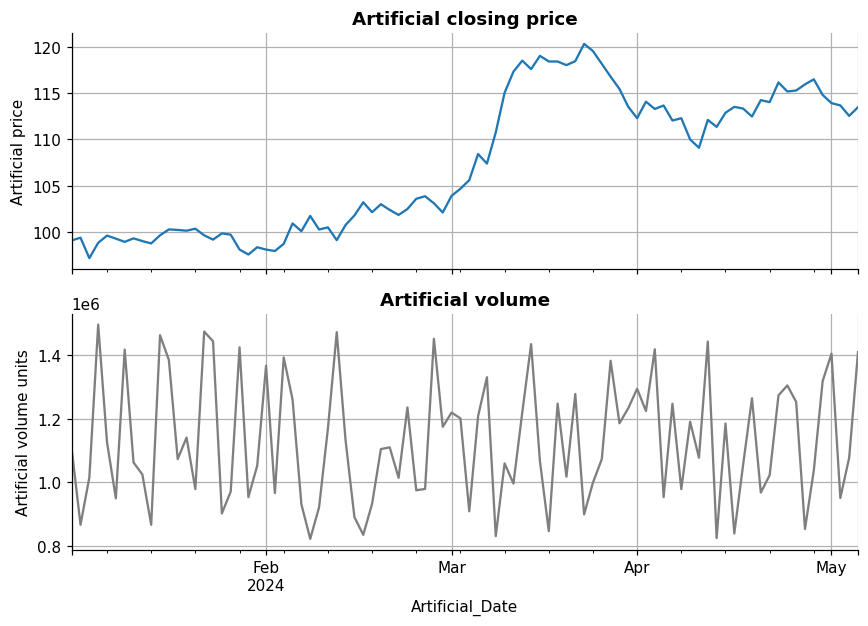

In [10]:
# Purpose: calculate the controlled example for Issue 5.
rng = np.random.default_rng(2026)
feature_dates = pd.bdate_range("2024-01-02", periods=90)
artificial_log_return = rng.normal(0.0002, 0.012, len(feature_dates))
artificial_close = 100 * np.exp(np.cumsum(artificial_log_return))
artificial_open = artificial_close * (1 + rng.normal(0, 0.0025, len(feature_dates)))
artificial_high = np.maximum(artificial_open, artificial_close) * (1 + rng.uniform(0.001, 0.010, len(feature_dates)))
artificial_low = np.minimum(artificial_open, artificial_close) * (1 - rng.uniform(0.001, 0.010, len(feature_dates)))
artificial_volume = rng.integers(800_000, 1_500_000, len(feature_dates))

features = pd.DataFrame(
    {
        "Open": artificial_open,
        "High": artificial_high,
        "Low": artificial_low,
        "Close": artificial_close,
        "Volume": artificial_volume,
    },
    index=feature_dates,
)
features.index.name = "Artificial_Date"
features["ret_1d"] = features["Close"].pct_change(fill_method=None)

input_audit = pd.Series(
    {
        "rows": len(features),
        "unique_index": features.index.is_unique,
        "sorted_index": features.index.is_monotonic_increasing,
        "missing_price_values": int(features[["Open", "High", "Low", "Close"]].isna().sum().sum()),
        "nonfinite_price_values": int((~np.isfinite(features[["Open", "High", "Low", "Close"]])).sum().sum()),
        "nonpositive_price_values": int(features[["Open", "High", "Low", "Close"]].le(0).sum().sum()),
        "ohlc_range_violations": int((
            (features["High"] < features[["Open", "Close"]].max(axis=1))
            | (features["Low"] > features[["Open", "Close"]].min(axis=1))
            | (features["High"] < features["Low"])
        ).sum()),
        "negative_volume_values": int(features["Volume"].lt(0).sum()),
        "missing_first_returns": int(features["ret_1d"].isna().sum()),
    },
    name="Audit result",
)
display(features.head(4).round(4))
display(features.tail(4).round(4))
display(input_audit.rename_axis("Check").to_frame())

fig, axes = plt.subplots(2, 1, figsize=(8.0, 5.8), sharex=True)
features["Close"].plot(ax=axes[0], color="tab:blue")
axes[0].set_ylabel("Artificial price")
axes[0].set_title("Artificial closing price")
features["Volume"].plot(ax=axes[1], color="tab:grey")
axes[1].set_ylabel("Artificial volume units")
axes[1].set_title("Artificial volume")
plt.tight_layout()
plt.show()

assert input_audit["rows"] == 90
assert input_audit["unique_index"] and input_audit["sorted_index"]
assert input_audit["missing_price_values"] == 0
assert input_audit["nonfinite_price_values"] == 0
assert input_audit["nonpositive_price_values"] == 0
assert input_audit["ohlc_range_violations"] == 0
assert input_audit["missing_first_returns"] == 1

### Interpretation of the controlled output


The table contains 90 ordered artificial rows, positive finite prices, nonnegative volume, and one expected missing first return. The figure makes the price and volume paths visible but does not make either series a real observation. All later interpretations inherit this artificial-data boundary.


### Source-grounded example and prediction

Code 2 audits the AAPL response before calculating an indicator. It checks date order, duplicate labels, finite positive OHLC values, the within-row OHLC identities, nonnegative volume, and the expected first missing return. It reports only summary counts rather than downloaded market rows.

#### Source connection

The source-grounded AAPL input retains the symbol, request interval, field names, and explicit `auto_adjust=False` setting. Passing row-order and OHLC checks does not verify Yahoo Finance's construction of every field or the publication time of each daily row.

Sources: [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html); [yfinance project notice](https://ranaroussi.github.io/yfinance/index.html).

**Prediction before execution.** Predict which AAPL audit counts should be zero and whether the returned response has one missing first return.


In [11]:
# Purpose: calculate the source-grounded example for Issue 5.
aapl_real = load_us_daily("AAPL")
real_ohlc = aapl_real[["Open", "High", "Low", "Close"]]
real_input_audit = pd.Series(
    {
        "rows": len(aapl_real),
        "sorted date labels": aapl_real.index.is_monotonic_increasing,
        "duplicate date labels": int(aapl_real.index.duplicated().sum()),
        "missing OHLC values": int(real_ohlc.isna().sum().sum()),
        "nonfinite OHLC values": int((~np.isfinite(real_ohlc)).sum().sum()),
        "nonpositive OHLC values": int(real_ohlc.le(0).sum().sum()),
        "high below open or close": int((aapl_real["High"] < aapl_real[["Open", "Close"]].max(axis=1)).sum()),
        "low above open or close": int((aapl_real["Low"] > aapl_real[["Open", "Close"]].min(axis=1)).sum()),
        "negative volume values": int(aapl_real["Volume"].lt(0).sum()),
        "missing first simple returns": int(aapl_real["Close"].pct_change(fill_method=None).isna().sum()),
    },
    name="Observed result",
)
display(real_input_audit.to_frame())
assert real_input_audit["rows"] > 20
assert real_input_audit[["duplicate date labels", "nonfinite OHLC values", "nonpositive OHLC values", "high below open or close", "low above open or close", "negative volume values"]].eq(0).all()

,Observed result
rows,124
sorted date labels,True
duplicate date labels,0
missing OHLC values,0
nonfinite OHLC values,0
nonpositive OHLC values,0
high below open or close,0
low above open or close,0
negative volume values,0
missing first simple returns,1


### Interpretation of the source-grounded output


The summary reports 124 ordered AAPL rows, zero duplicate labels, zero missing or nonfinite OHLC values, zero nonpositive prices, zero checked OHLC-order violations, and zero negative Volume values. It also reports one expected missing first return. These checks establish internal suitability for the stated calculations, not the provider's publication time, adjustment methodology, or economic accuracy.


### Discussion questions

1. The 90-row artificial table passes all assertions, but its source, currency, time zone, and corporate-action treatment are absent. Choose the two missing facts that could most directly change a return-based feature and explain a concrete failure for each.
2. A duplicate date contains two different closing prices. Decide whether sorting, averaging, or deleting one row is defensible from the table alone. State the additional source evidence required before any feature calculation may continue.


## Issue 6 — What does a simple moving average retain and omit?


A simple moving average over $k$ observations assigns equal weight to the $k$ included price levels and no weight to earlier values. For a positive, ordered price series,

$$
\mathrm{SMA}^{(k)}_t=\frac{1}{k}\sum_{j=0}^{k-1}P_{t-j}.
$$

Each included price has weight $1/k$, so the weights sum to one. The result retains the same currency-per-share unit as $P_t$. It smooths the observed price path but does not by itself measure a return, predict direction, or establish a trend that will continue.

The five- and twenty-session means below use trailing windows ending at the current artificial close. `min_periods` equals the window size so the notebook does not create partially defined early values.


### Controlled example and prediction

Code 1 calculates five-price and twenty-price simple moving averages from the audited artificial Close series.

**Prediction before execution.** Predict the first valid date and initial missing count of the five- and twenty-price artificial means.


,Close,sma_5,sma_20
Artificial_Date,,,
2024-01-23,99.6289,100.1186,NaN
2024-01-24,99.1672,99.8977,NaN
2024-01-25,99.8418,99.8231,NaN
2024-01-26,99.7055,99.7378,NaN
2024-01-29,98.0941,99.2875,99.3171
2024-01-30,97.5534,98.8724,99.2411
2024-01-31,98.3448,98.7079,99.1894
2024-02-01,98.0907,98.3577,99.2359
2024-02-02,97.9354,98.0037,99.1915


,First_valid_date,Required_prices,Initial_missing_values,Unit
sma_5,2024-01-08,5,4,Artificial price units
sma_20,2024-01-29,20,19,Artificial price units


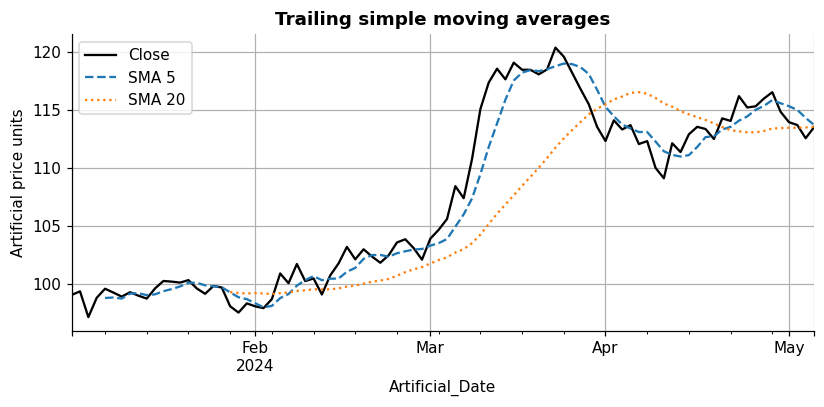

In [12]:
# Purpose: calculate the controlled example for Issue 6.
features["sma_5"] = features["Close"].rolling(5, min_periods=5).mean()
features["sma_20"] = features["Close"].rolling(20, min_periods=20).mean()

sma_first_valid = pd.DataFrame(
    {
        "First_valid_date": [features["sma_5"].first_valid_index(), features["sma_20"].first_valid_index()],
        "Required_prices": [5, 20],
        "Initial_missing_values": [features["sma_5"].isna().sum(), features["sma_20"].isna().sum()],
        "Unit": ["Artificial price units", "Artificial price units"],
    },
    index=["sma_5", "sma_20"],
)
display(features[["Close", "sma_5", "sma_20"]].iloc[15:24].round(4))
display(sma_first_valid)

ax = features[["Close", "sma_5", "sma_20"]].plot(color=["black", "tab:blue", "tab:orange"], style=["-", "--", ":"])
ax.set_ylabel("Artificial price units")
ax.set_title("Trailing simple moving averages")
ax.legend(["Close", "SMA 5", "SMA 20"])
plt.tight_layout()
plt.show()

assert features["sma_5"].isna().sum() == 4
assert features["sma_20"].isna().sum() == 19

### Interpretation of the controlled output


The five-price mean first appears on 2024-01-08 after four missing values; the twenty-price mean first appears on 2024-01-29 after 19. On 2024-01-29 they equal 99.2875 and 99.3171 artificial price units. Both retain the input unit, and the figure does not establish which window predicts a later outcome.


### Source-grounded example and prediction

Code 2 calculates a five-session simple moving average from the recorded AAPL Close request. The table displays derived moving-average values, and the figure compares the Close and moving average after both are rebased to 100 on the first valid date. Rebased lines make relative movement visible without reproducing a table of downloaded rows.

#### Source connection

The AAPL example applies pandas `rolling` to an unadjusted Close series requested through yfinance. Pandas documents the window calculation; yfinance documents the request interface. Neither source claims that a five-session average predicts a future AAPL return.

Sources: [pandas rolling-window documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html); [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html).

**Prediction before execution.** Predict whether the AAPL five-price mean has four initial missing values and the direction of its final displayed one-row change.


,SMA_5_USD,One_day_change_in_SMA_USD
Date,,
2024-06-24,211.254,-0.870
2024-06-25,209.734,-1.520
2024-06-26,209.526,-0.208
2024-06-27,210.410,0.884
2024-06-28,211.036,0.626


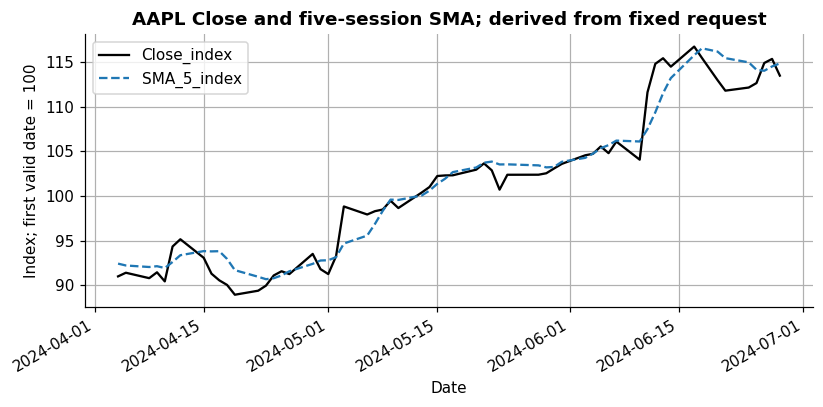

In [13]:
# Purpose: calculate the source-grounded example for Issue 6.
aapl_real = load_us_daily("AAPL")
real_sma = aapl_real["Close"].rolling(5, min_periods=5).mean().rename("SMA_5_USD")
real_sma_output = pd.DataFrame(
    {
        "SMA_5_USD": real_sma.dropna().tail(5),
        "One_day_change_in_SMA_USD": real_sma.diff().dropna().tail(5),
    }
)
display(real_sma_output.round(4))
first_sma_date = real_sma.first_valid_index()
rebased_sma = pd.DataFrame({"Close_index": aapl_real.loc[first_sma_date:, "Close"], "SMA_5_index": real_sma.loc[first_sma_date:]})
rebased_sma = 100 * rebased_sma / rebased_sma.iloc[0]
ax = rebased_sma.tail(60).plot(color=["black", "tab:blue"], style=["-", "--"])
ax.set_ylabel("Index; first valid date = 100")
ax.set_title("AAPL Close and five-session SMA; derived from fixed request")
plt.tight_layout(); plt.show()
assert real_sma.isna().sum() == 4

### Interpretation of the source-grounded output


The five displayed AAPL SMA values run from 211.2540 USD on 2024-06-24 to 211.0360 USD on 2024-06-28. Their one-row changes range from -1.5200 USD to 0.8840 USD in this displayed segment. The assertion confirms four initial missing values, so the first mean appears only after five prices; neither the table nor rebased figure establishes predictive value.


### Discussion questions

1. For the first valid five-session average, list all five price dates and reproduce the value by hand. Then replace the oldest price with an extreme value and explain exactly how long that change remains in the trailing average.
2. A team selects the shorter moving average because its final signal gives the highest later return. Identify which design choice has used evaluation evidence, and propose a validation-stage comparison that would preserve a separate final period.


## Issue 7 — How does an exponentially weighted mean differ from a simple moving average?


An exponentially weighted mean assigns larger weights to more recent observations under a specified decay parameter. With `adjust=False`, pandas applies the recursion

$$
E_t=\alpha P_t+(1-\alpha)E_{t-1},
\qquad
\alpha=\frac{2}{\text{span}+1}.
$$

For `span=5`, $\alpha=1/3$. Older observations keep declining indirect weight through $E_{t-1}$; the span is therefore not a strict five-row cutoff. Initialization, `adjust`, and `min_periods` are part of the calculation and must be recorded. $E_t$ retains the price unit.

The example uses `span=5`, `adjust=False`, and `min_periods=5`. It compares the result with the five-session simple moving average without asserting that either measure is a better predictor.


### Controlled example and prediction

Code 1 compares a five-price simple moving average with an exponentially weighted mean under explicit `span`, `adjust`, and `min_periods` settings.

**Prediction before execution.** Predict whether the artificial SMA and exponentially weighted mean share a first valid date but differ in value.


,Setting,Value
0,span,5
1,adjust,False
2,min_periods,5
3,input,Close through t
4,unit,Artificial price units
5,first valid date,2024-01-08 00:00:00


,Close,sma_5,ewm_5
Artificial_Date,,,
2024-01-02,99.0726,NaN,NaN
2024-01-03,99.3789,NaN,NaN
2024-01-04,97.1624,NaN,NaN
2024-01-05,98.8233,NaN,NaN
2024-01-08,99.6030,98.8080,98.9412
2024-01-09,99.2744,98.8484,99.0523
2024-01-10,98.9233,98.7573,99.0093
2024-01-11,99.3045,99.1857,99.1077
2024-01-12,99.0058,99.2222,99.0737


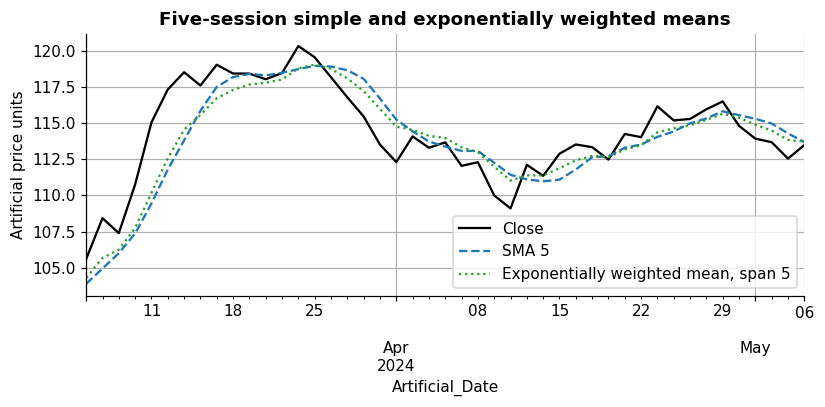

In [14]:
# Purpose: calculate the controlled example for Issue 7.
features["ewm_5"] = features["Close"].ewm(
    span=5,
    adjust=False,
    min_periods=5,
).mean()

ewm_record = pd.DataFrame(
    {
        "Setting": ["span", "adjust", "min_periods", "input", "unit", "first valid date"],
        "Value": [5, False, 5, "Close through t", "Artificial price units", features["ewm_5"].first_valid_index()],
    }
)
display(ewm_record)
display(features[["Close", "sma_5", "ewm_5"]].head(10).round(4))

ax = features[["Close", "sma_5", "ewm_5"]].tail(45).plot(color=["black", "tab:blue", "tab:green"], style=["-", "--", ":"])
ax.set_ylabel("Artificial price units")
ax.set_title("Five-session simple and exponentially weighted means")
ax.legend(["Close", "SMA 5", "Exponentially weighted mean, span 5"])
plt.tight_layout()
plt.show()

assert features["ewm_5"].isna().sum() == 4
assert features["ewm_5"].notna().sum() == features["sma_5"].notna().sum()

### Interpretation of the controlled output


With `span=5`, `adjust=False`, and `min_periods=5`, both series first appear on 2024-01-08. On that date the SMA is 98.8080 and the exponentially weighted mean is 98.9412 artificial price units, so equal first-valid dates do not imply equal values. This difference follows from the weighting rule, not predictive evidence.


### Source-grounded example and prediction

Code 2 compares a five-price SMA with an exponentially weighted mean using `span=5`, `adjust=False`, and `min_periods=5` on the same AAPL Close input. Holding the data and first-valid-date rule fixed isolates the effect of the weighting rule.

#### Source connection

Pandas documents the `ewm` decay settings, including `span`, `adjust`, and `min_periods`. A real AAPL price series still requires the same market-field and timing checks before the software result could be interpreted financially.

Sources: [pandas exponentially weighted calculation documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.ewm.html); [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html).

**Prediction before execution.** Predict whether the AAPL mean absolute difference between the two calculations is zero or positive under fixed settings.


,Observed result
first valid SMA date,2024-01-08
first valid EWM date,2024-01-08
mean absolute difference (USD),0.685423
maximum absolute difference (USD),2.498754
last EWM minus SMA (USD),0.370108


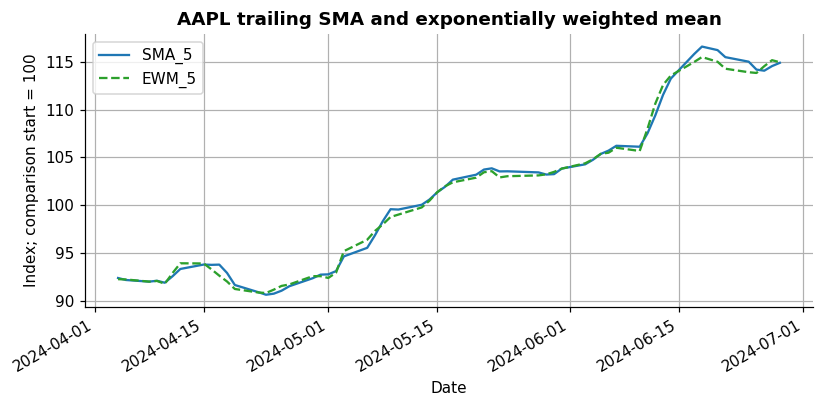

In [15]:
# Purpose: calculate the source-grounded example for Issue 7.
aapl_real = load_us_daily("AAPL")
real_sma_5 = aapl_real["Close"].rolling(5, min_periods=5).mean()
real_ewm_5 = aapl_real["Close"].ewm(span=5, adjust=False, min_periods=5).mean()
real_weight_comparison = pd.Series(
    {
        "first valid SMA date": str(real_sma_5.first_valid_index().date()),
        "first valid EWM date": str(real_ewm_5.first_valid_index().date()),
        "mean absolute difference (USD)": float((real_ewm_5 - real_sma_5).abs().dropna().mean()),
        "maximum absolute difference (USD)": float((real_ewm_5 - real_sma_5).abs().dropna().max()),
        "last EWM minus SMA (USD)": float((real_ewm_5 - real_sma_5).dropna().iloc[-1]),
    },
    name="Observed result",
)
display(real_weight_comparison.to_frame().round(4))
comparison = pd.DataFrame({"SMA_5": real_sma_5, "EWM_5": real_ewm_5}).dropna()
comparison = 100 * comparison / comparison.iloc[0]
ax = comparison.tail(60).plot(color=["tab:blue", "tab:green"], style=["-", "--"])
ax.set_ylabel("Index; comparison start = 100")
ax.set_title("AAPL trailing SMA and exponentially weighted mean")
plt.tight_layout(); plt.show()
assert real_sma_5.first_valid_index() == real_ewm_5.first_valid_index()

### Interpretation of the source-grounded output


The AAPL SMA and exponentially weighted mean both first appear on 2024-01-08. Their mean absolute difference is 0.6854 USD, the maximum is 2.4988 USD, and the final exponentially weighted mean exceeds the SMA by 0.3701 USD. The figure therefore isolates a weighting difference rather than a data-period difference; it does not show which calculation predicts later returns.


### Discussion questions

1. Two students both report `span=5`; one uses `adjust=True` and the other `adjust=False`. Decide whether their early values are expected to match, identify the missing reproducibility setting, and describe the smallest table that would reveal the difference.
2. A one-day price jump occurs and then prices return to their earlier level. Compare how a five-price SMA and the stated exponentially weighted mean retain the jump over later dates. Defend which measure reacts faster without claiming which predicts better.


## Issue 8 — What does a moving-average gap measure?


A moving-average gap compares a shorter trailing price average with a longer one. For short window $k_s$ and long window $k_l$, with $k_s<k_l$ and a nonzero long average, define

$$
g_t=\frac{\mathrm{SMA}^{(k_s)}_t}{\mathrm{SMA}^{(k_l)}_t}-1.
$$

Both price units cancel, so $g_t$ is a decimal relative difference. A positive value means only that the short mean is above the long mean at that endpoint.

The gap cannot be interpreted before both component means exist. Its sign is a feature value, not yet a signal, position, or forecast.


### Controlled example and prediction

Code 1 calculates the relative difference between the five-price and twenty-price artificial moving averages after both values become available.

**Prediction before execution.** Predict which component determines the artificial gap's first valid date and how many initial values are missing.


,Close,sma_5,sma_20,ma_gap_5_20
Artificial_Date,,,,
2024-01-24,99.167216,99.897716,NaN,NaN
2024-01-25,99.841767,99.823118,NaN,NaN
2024-01-26,99.705497,99.737810,NaN,NaN
2024-01-29,98.094146,99.287509,99.317097,-0.000298
2024-01-30,97.553442,98.872414,99.241140,-0.003715
2024-01-31,98.344814,98.707933,99.189437,-0.004854
2024-02-01,98.090686,98.357717,99.235852,-0.008849
2024-02-02,97.935355,98.003689,99.191457,-0.011975
2024-02-05,98.712310,98.127321,99.146922,-0.010284


,Value
Item,
first_valid_date,2024-01-29 00:00:00
initial_missing_values,19
positive_values,48
nonpositive_values,23
unit,decimal relative difference


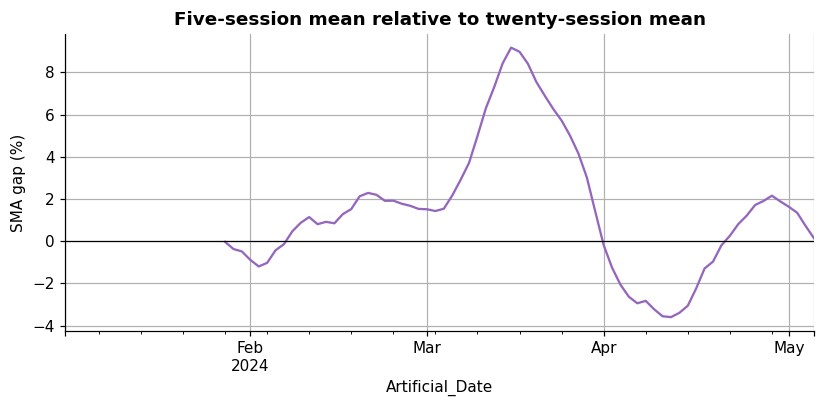

In [16]:
# Purpose: calculate the controlled example for Issue 8.
features["ma_gap_5_20"] = features["sma_5"] / features["sma_20"] - 1

gap_table = features[["Close", "sma_5", "sma_20", "ma_gap_5_20"]].iloc[16:25].copy()
display(gap_table.round(6))
gap_summary = pd.Series(
    {
        "first_valid_date": features["ma_gap_5_20"].first_valid_index(),
        "initial_missing_values": int(features["ma_gap_5_20"].isna().sum()),
        "positive_values": int(features["ma_gap_5_20"].gt(0).sum()),
        "nonpositive_values": int(features["ma_gap_5_20"].le(0).sum()),
        "unit": "decimal relative difference",
    },
    name="Value",
)
display(gap_summary.rename_axis("Item").to_frame())

ax = (100 * features["ma_gap_5_20"]).plot(color="tab:purple")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("SMA gap (%)")
ax.set_title("Five-session mean relative to twenty-session mean")
plt.tight_layout()
plt.show()

assert features["ma_gap_5_20"].first_valid_index() == features["sma_20"].first_valid_index()
assert features["ma_gap_5_20"].dropna().shape[0] == len(features) - 19

### Interpretation of the controlled output


The gap begins on 2024-01-29 with 19 initial missing values. Its first value is -0.000298, meaning the five-price mean is about 0.0298% below the twenty-price mean at that endpoint. Across the artificial sample, 48 values are positive and 23 are nonpositive; those counts do not demonstrate a subsequent return.


### Source-grounded example and prediction

Code 2 calculates the relative gap between AAPL five- and twenty-session simple moving averages. Both means use the same unadjusted Close field and endpoint, so the factor that changes is the lookback. The output is a derived dimensionless series.

#### Source connection

A moving-average gap calculated from AAPL closing prices inherits the field's corporate-action treatment and publication boundary. The provider response supplies the requested rows; it does not define the short and long windows or turn their difference into a trading recommendation.

Sources: [pandas rolling-window documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html); [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html).

**Prediction before execution.** Predict the AAPL gap's first valid date and whether both positive and nonpositive values occur.


,Observed result
first valid date,2024-01-30
initial missing values,19
positive observations,50
nonpositive observations,55
minimum gap (%),-5.151285
maximum gap (%),7.869381


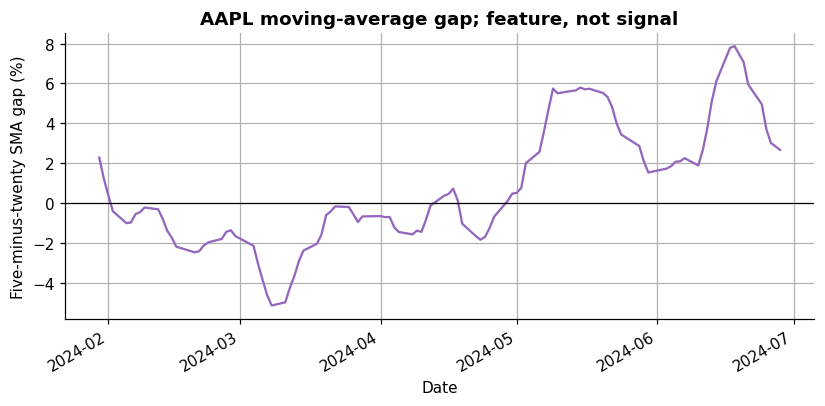

In [17]:
# Purpose: calculate the source-grounded example for Issue 8.
aapl_real = load_us_daily("AAPL")
real_sma_5 = aapl_real["Close"].rolling(5, min_periods=5).mean()
real_sma_20 = aapl_real["Close"].rolling(20, min_periods=20).mean()
real_gap = (real_sma_5 / real_sma_20 - 1).rename("MA_gap")
real_gap_summary = pd.Series(
    {
        "first valid date": str(real_gap.first_valid_index().date()),
        "initial missing values": int(real_gap.isna().sum()),
        "positive observations": int(real_gap.gt(0).sum()),
        "nonpositive observations": int(real_gap.le(0).sum()),
        "minimum gap (%)": 100 * float(real_gap.min()),
        "maximum gap (%)": 100 * float(real_gap.max()),
    },
    name="Observed result",
)
display(real_gap_summary.to_frame().round(4))
ax = (100 * real_gap).plot(color="tab:purple")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Five-minus-twenty SMA gap (%)")
ax.set_title("AAPL moving-average gap; feature, not signal")
plt.tight_layout(); plt.show()
assert real_gap.isna().sum() == 19

### Interpretation of the source-grounded output


The AAPL gap first appears on 2024-01-30 after 19 initial missing values because the twenty-session component determines availability. It is positive on 50 observations and nonpositive on 55, with an observed range from -5.1513% to 7.8694%. None of those counts assigns a signal or a future return.


### Discussion questions

1. A two-for-one split is present in the short-average input but not consistently represented in the long-average input. Predict the direction of the resulting gap error and explain why normalizing by the long average does not repair the field inconsistency.
2. The gap is positive but five-session momentum is negative on the same date. Explain how both can be correct by identifying their different source windows, then state what additional rule would be needed before either becomes a signal.


## Issue 9 — How is trailing momentum defined here?


The Week 3 momentum feature is the simple price return from the close at $t-k$ to the close at $t$:

$$
m_t^{(k)}=\frac{P_t}{P_{t-k}}-1.
$$

The two prices must use the same field, currency, unit, and corporate-action convention. The calculation uses $k+1$ price endpoints and is available only after the close at $t$ is published. Its unit is a decimal return.

This classroom five- and twenty-session calculation is not the same design as academic momentum studies with different formation periods, holding periods, assets, and portfolio rules. A standard term does not make every implementation equivalent.


### Controlled example and prediction

Code 1 calculates five-session and twenty-session momentum from the same artificial Close series while changing only the lookback.

**Prediction before execution.** Predict the number of prices and first valid date required by each artificial momentum lookback.


,Formula,Prices_required,First_valid_date,Unit,Latest_input
mom_5,Close[t] / Close[t-5] - 1,6,2024-01-09,decimal return,Close at t
mom_20,Close[t] / Close[t-20] - 1,21,2024-01-30,decimal return,Close at t


,Close,mom_5,mom_20
Artificial_Date,,,
2024-01-25,99.841767,-0.003722,NaN
2024-01-26,99.705497,-0.004260,NaN
2024-01-29,98.094146,-0.022437,NaN
2024-01-30,97.553442,-0.020832,-0.015334
2024-01-31,98.344814,-0.008293,-0.010405
2024-02-01,98.090686,-0.017539,0.009554
2024-02-02,97.935355,-0.017754,-0.008985
2024-02-05,98.712310,0.006302,-0.008943


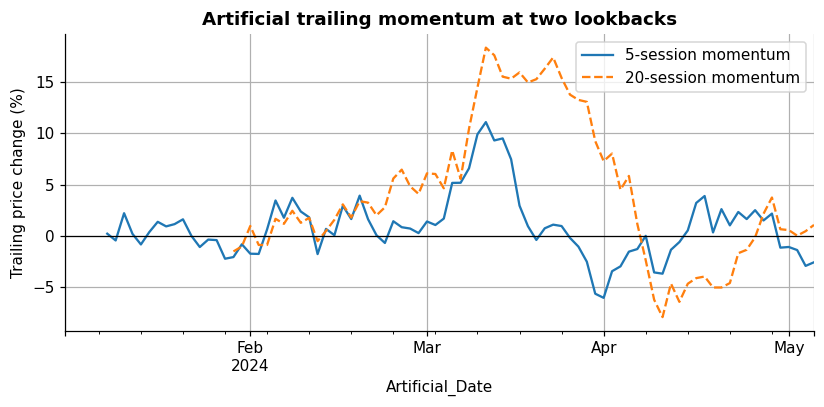

In [18]:
# Purpose: calculate the controlled example for Issue 9.
features["mom_5"] = features["Close"] / features["Close"].shift(5) - 1
features["mom_20"] = features["Close"] / features["Close"].shift(20) - 1

momentum_record = pd.DataFrame(
    {
        "Formula": ["Close[t] / Close[t-5] - 1", "Close[t] / Close[t-20] - 1"],
        "Prices_required": [6, 21],
        "First_valid_date": [features["mom_5"].first_valid_index(), features["mom_20"].first_valid_index()],
        "Unit": ["decimal return", "decimal return"],
        "Latest_input": ["Close at t", "Close at t"],
    },
    index=["mom_5", "mom_20"],
)
display(momentum_record)
display(features[["Close", "mom_5", "mom_20"]].iloc[17:25].round(6))

ax = (100 * features[["mom_5", "mom_20"]]).plot(color=["tab:blue", "tab:orange"], style=["-", "--"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Trailing price change (%)")
ax.set_title("Artificial trailing momentum at two lookbacks")
ax.legend(["5-session momentum", "20-session momentum"])
plt.tight_layout()
plt.show()

assert features["mom_5"].isna().sum() == 5
assert features["mom_20"].isna().sum() == 20

### Interpretation of the controlled output


Five-session momentum first appears on 2024-01-09 after six prices; twenty-session momentum first appears on 2024-01-30 after twenty-one. On 2024-02-01 the two values have opposite signs, -0.017539 and 0.009554. This sensitivity is an input to later evaluation, not a reason to retain whichever lookback looks best after inspecting outcomes.


### Source-grounded example and prediction

Code 2 calculates five- and twenty-session simple price momentum from the same AAPL Close series. The data, endpoint, price field, and return definition are fixed; only the lookback changes. The comparison shows why a paper's momentum horizon cannot be replaced by an arbitrary classroom horizon without changing the method.

#### Source connection

Jegadeesh and Titman (1993) provide published evidence about a specific momentum design. Their formation periods, holding periods, assets, and portfolio construction differ from this five-session classroom price change, so the paper cannot be cited as evidence for the classroom signal.

Sources: [Jegadeesh and Titman (1993)](https://doi.org/10.1111/j.1540-6261.1993.tb04702.x); [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html).

**Prediction before execution.** Predict whether the five- and twenty-session AAPL momentum signs ever disagree on a common date.


,Observed result
first valid 5-session date,2024-01-09
first valid 20-session date,2024-01-31
dates with opposite signs,33
largest 5-session momentum (%),12.194492
smallest 5-session momentum (%),-6.84992


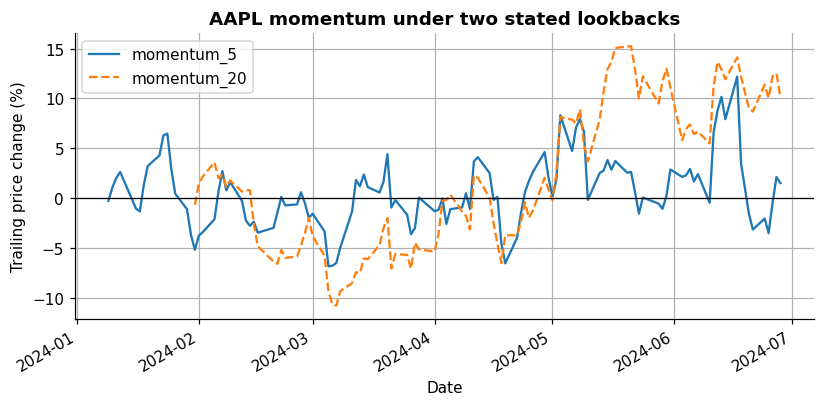

In [19]:
# Purpose: calculate the source-grounded example for Issue 9.
aapl_real = load_us_daily("AAPL")
real_momentum = pd.DataFrame(index=aapl_real.index)
real_momentum["momentum_5"] = aapl_real["Close"] / aapl_real["Close"].shift(5) - 1
real_momentum["momentum_20"] = aapl_real["Close"] / aapl_real["Close"].shift(20) - 1
both_real_momentum = real_momentum.dropna()
real_momentum_summary = pd.Series(
    {
        "first valid 5-session date": str(real_momentum["momentum_5"].first_valid_index().date()),
        "first valid 20-session date": str(real_momentum["momentum_20"].first_valid_index().date()),
        "dates with opposite signs": int((np.sign(both_real_momentum["momentum_5"]) != np.sign(both_real_momentum["momentum_20"])).sum()),
        "largest 5-session momentum (%)": 100 * float(real_momentum["momentum_5"].max()),
        "smallest 5-session momentum (%)": 100 * float(real_momentum["momentum_5"].min()),
    },
    name="Observed result",
)
display(real_momentum_summary.to_frame().round(4))
ax = (100 * real_momentum).plot(color=["tab:blue", "tab:orange"], style=["-", "--"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Trailing price change (%)")
ax.set_title("AAPL momentum under two stated lookbacks")
plt.tight_layout(); plt.show()
assert real_momentum["momentum_5"].isna().sum() == 5
assert real_momentum["momentum_20"].isna().sum() == 20

### Interpretation of the source-grounded output


Five-session AAPL momentum first appears on 2024-01-09, while twenty-session momentum first appears on 2024-01-31. Their signs disagree on 33 common dates, and five-session momentum ranges from -6.8499% to 12.1945%. This is direct evidence that lookback choice changes the feature, not evidence that one lookback is financially superior.


### Discussion questions

1. For a momentum value labeled at date t, identify the two price dates used for five-session momentum and calculate which observation must be available last. Reject a student's claim that only five price observations are required.
2. Five-session and twenty-session momentum have opposite signs. A team keeps the lookback with the better final-period return. Explain why that choice contaminates the final period and specify what evidence could be used to choose the lookback earlier.


## Issue 10 — What does rolling volatility measure?


Rolling volatility summarizes dispersion in a trailing return window. With $k$ decimal one-session simple returns and the sample-standard-deviation convention, the annualized classroom measure is

$$
\widehat{\sigma}^{(k)}_t
=\sqrt{252}\sqrt{\frac{1}{k-1}\sum_{j=0}^{k-1}\left(r_{t-j}-\bar r_t^{(k)}\right)^2}.
$$

The example uses $k=20$. Both `ddof=1` and 252 are explicit conventions; 252 is not a property read from the data. The result is an annualized decimal volatility and is multiplied by 100 only for percentage display.

Volatility is not a directional forecast. A high value says that the recent artificial returns were more dispersed under this calculation; it does not say the next return will be negative or positive.


### Controlled example and prediction

Code 1 calculates annualized rolling volatility from twenty artificial one-session returns under one stated standard-deviation and annualization convention.

**Prediction before execution.** Predict the first valid date and missing count of the artificial twenty-return volatility series.


,Recorded value
Item,
input,twenty one-session simple returns ending at t
lookback,20
ddof,1
annualization_factor,sqrt(252)
unit,annualized decimal volatility under the classr...
first_valid_date,2024-01-30 00:00:00
initial_missing_values,20


,ret_1d,vol_20
Artificial_Date,,
2024-01-25,0.006802,NaN
2024-01-26,-0.001365,NaN
2024-01-29,-0.016161,NaN
2024-01-30,-0.005512,0.138281
2024-01-31,0.008112,0.141241
2024-02-01,-0.002584,0.115913
2024-02-02,-0.001584,0.098033
2024-02-05,0.007933,0.098081


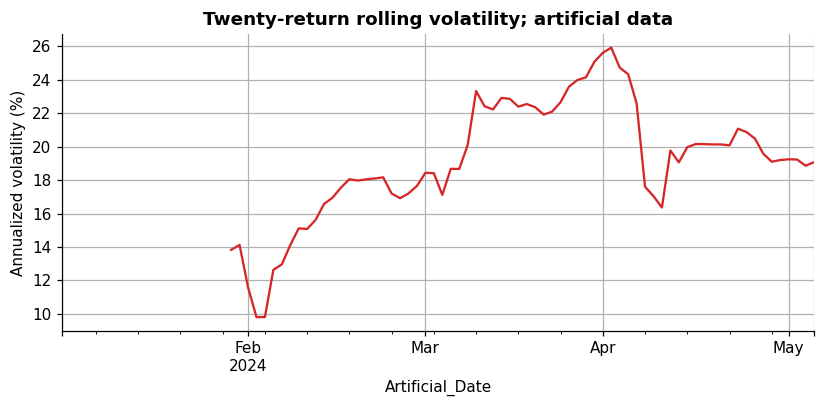

In [20]:
# Purpose: calculate the controlled example for Issue 10.
features["vol_20"] = (
    features["ret_1d"].rolling(20, min_periods=20).std(ddof=1) * np.sqrt(252)
)

volatility_record = pd.Series(
    {
        "input": "twenty one-session simple returns ending at t",
        "lookback": 20,
        "ddof": 1,
        "annualization_factor": "sqrt(252)",
        "unit": "annualized decimal volatility under the classroom convention",
        "first_valid_date": features["vol_20"].first_valid_index(),
        "initial_missing_values": int(features["vol_20"].isna().sum()),
    },
    name="Recorded value",
)
display(volatility_record.rename_axis("Item").to_frame())
display(features[["ret_1d", "vol_20"]].iloc[17:25].round(6))

ax = (100 * features["vol_20"]).plot(color="tab:red")
ax.set_ylabel("Annualized volatility (%)")
ax.set_title("Twenty-return rolling volatility; artificial data")
plt.tight_layout()
plt.show()

assert features["vol_20"].isna().sum() == 20
assert features["vol_20"].dropna().ge(0).all()

### Interpretation of the controlled output


The first valid twenty-return volatility is 0.138281 on 2024-01-30 after twenty initial missing values and twenty-one prices. The figure displays this decimal result as about 13.83%. The factor 252 is a stated classroom annualization assumption, not the observed number of sessions in every market or year.


### Source-grounded example and prediction

Code 2 calculates annualized twenty-return volatility from AAPL one-session simple returns. It then recomputes the same windows with `ddof=0` and `ddof=1`. The data, window, and annualization factor remain fixed so the displayed difference isolates the degrees-of-freedom convention.

#### Source connection

A volatility estimate built from AAPL returns requires a stated price field, window, degrees-of-freedom convention, and annualization assumption. The yfinance response supplies requested rows; the factor 252 remains an explicit classroom assumption.

Sources: [pandas rolling-window documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html); [pandas fractional-change documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.pct_change.html).

**Prediction before execution.** Predict which AAPL volatility convention produces the larger value and the size of their maximum percentage-point difference.


,Observed result
first valid date,2024-01-31
initial missing values,20
"mean annualized volatility, ddof=1 (%)",22.895433
"mean annualized volatility, ddof=0 (%)",22.315707
maximum convention difference (percentage points),0.844223


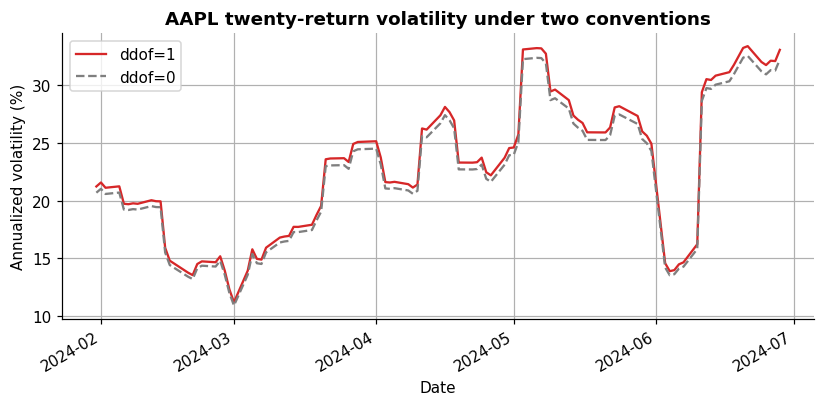

In [21]:
# Purpose: calculate the source-grounded example for Issue 10.
aapl_real = load_us_daily("AAPL")
real_return = aapl_real["Close"].pct_change(fill_method=None)
real_vol_ddof1 = real_return.rolling(20, min_periods=20).std(ddof=1) * np.sqrt(252)
real_vol_ddof0 = real_return.rolling(20, min_periods=20).std(ddof=0) * np.sqrt(252)
real_vol_summary = pd.Series(
    {
        "first valid date": str(real_vol_ddof1.first_valid_index().date()),
        "initial missing values": int(real_vol_ddof1.isna().sum()),
        "mean annualized volatility, ddof=1 (%)": 100 * float(real_vol_ddof1.mean()),
        "mean annualized volatility, ddof=0 (%)": 100 * float(real_vol_ddof0.mean()),
        "maximum convention difference (percentage points)": 100 * float((real_vol_ddof1 - real_vol_ddof0).abs().max()),
    },
    name="Observed result",
)
display(real_vol_summary.to_frame().round(4))
ax = (100 * pd.DataFrame({"ddof=1": real_vol_ddof1, "ddof=0": real_vol_ddof0})).plot(color=["tab:red", "tab:grey"], style=["-", "--"])
ax.set_ylabel("Annualized volatility (%)")
ax.set_title("AAPL twenty-return volatility under two conventions")
plt.tight_layout(); plt.show()
assert real_vol_ddof1.isna().sum() == 20
assert (real_vol_ddof1.dropna() >= real_vol_ddof0.dropna()).all()

### Interpretation of the source-grounded output


The AAPL volatility series first appears on 2024-01-31 after twenty missing values. Mean annualized volatility is 22.8954% with `ddof=1` and 22.3157% with `ddof=0`; the maximum gap is 0.8442 percentage points. The `ddof=1` series is at least as large for every complete window. This convention difference is not a data error or directional forecast.


### Discussion questions

1. Recalculate one twenty-return volatility value with `ddof=0` and `ddof=1`. Explain why the difference is a convention difference rather than a data error, and identify which value must be reported for another student to reproduce the notebook.
2. A student feeds percentage returns such as 1.2 rather than decimal returns such as 0.012 into the volatility calculation and then multiplies by 100 for display. Predict the scale error and identify the single boundary where conversion should occur.


## Issue 11 — What does the daily High–Low range relative to Close measure?

The daily High–Low range relative to Close compares the span between the recorded High and Low with the recorded Close on the same row. Let $H_t$, $L_t$, and $C_t$ be prices in USD per share for the same security, session, and field convention. When $C_t>0$ and $H_t\ge L_t$, define

$$
q_t=\frac{H_t-L_t}{C_t}.
$$

The price unit cancels, so $q_t$ is a decimal ratio. A value of 0.02 means the recorded High–Low span equals 2% of the Close. It does not reveal the sequence of intraday prices, realized volatility, liquidity, or the return earned by an investor. Those interpretations require different data and definitions.


### Controlled example and prediction

Code 1 uses the artificial OHLC values already audited in Issue 5. It calculates the ratio only after checking that High is not below Low and Close is positive.

**Prediction before execution.** Predict whether all 90 artificial ratios are available and nonnegative. Also predict the first ratio as a percent to four decimal places from the first displayed High, Low, and Close.


,High,Low,Close,range_ratio
Artificial_Date,,,,
2024-01-02 00:00:00,99.388546,98.876809,99.072580,0.005165
2024-01-03 00:00:00,100.071214,98.499150,99.378876,0.015819
2024-01-04 00:00:00,97.540701,96.269139,97.162385,0.013087
2024-01-05 00:00:00,99.065687,97.737930,98.823251,0.013436
2024-01-08 00:00:00,100.224553,99.350367,99.603017,0.008777
2024-01-09 00:00:00,100.293576,99.071404,99.274415,0.012311


,Controlled artificial result
observations,90.000000
available ratios,90.000000
negative ratios,0.000000
first ratio (%),0.516500
median ratio (%),1.369200
minimum ratio (%),0.516500
maximum ratio (%),2.240100


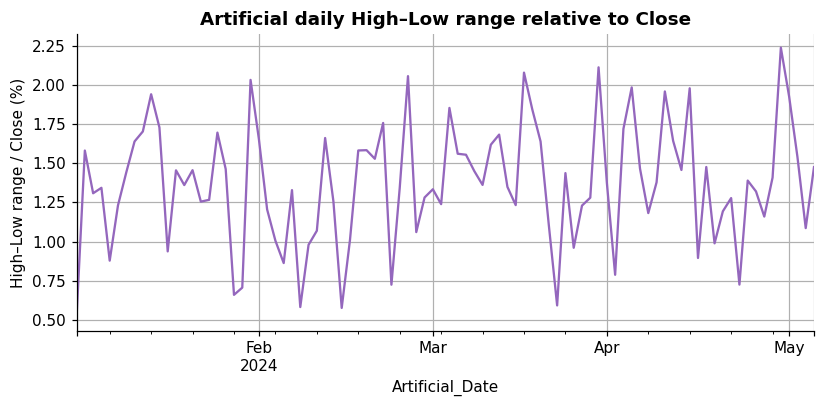

In [22]:
# Purpose: calculate and check the controlled daily High–Low range ratio.
features["range_ratio"] = (features["High"] - features["Low"]) / features["Close"]

controlled_range_rows = features[["High", "Low", "Close", "range_ratio"]].head(6).copy()
controlled_range_summary = pd.Series(
    {
        "observations": len(features),
        "available ratios": int(features["range_ratio"].notna().sum()),
        "negative ratios": int(features["range_ratio"].lt(0).sum()),
        "first ratio (%)": 100 * float(features["range_ratio"].iloc[0]),
        "median ratio (%)": 100 * float(features["range_ratio"].median()),
        "minimum ratio (%)": 100 * float(features["range_ratio"].min()),
        "maximum ratio (%)": 100 * float(features["range_ratio"].max()),
    },
    name="Controlled artificial result",
)
display(controlled_range_rows.round(6).style.set_caption(
    "Artificial OHLC prices and same-row High–Low range relative to Close; prices are artificial price units and ratios are decimal values."
))
display(controlled_range_summary.to_frame().round(4).style.set_caption(
    "Controlled price range summary for 90 artificial rows; percentage values equal 100 times the decimal ratio."
))

ax = (100 * features["range_ratio"]).plot(color="tab:purple")
ax.set_ylabel("High–Low range / Close (%)")
ax.set_title("Artificial daily High–Low range relative to Close")
plt.tight_layout()
plt.show()

assert features["range_ratio"].notna().all()
assert features["range_ratio"].ge(0).all()


### Interpretation of the controlled output

All 90 artificial rows produce a nonnegative ratio, and none is missing. The first ratio is 0.5165%, calculated from High 99.388546, Low 98.876809, and Close 99.072580 artificial price units. Across the artificial sample, the median is 1.3692%, with observed values from 0.5165% to 2.2401%. These results verify the formula for the artificial inputs; they do not establish an intraday path or a relationship with later returns.


### Source-grounded example and prediction

Code 2 applies the same ratio to the fixed AAPL daily response. The request supplies returned `High`, `Low`, and `Close` columns, while the calculation and financial interpretation remain the analyst's responsibility.

#### Source connection

The [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html) documents the historical-data request interface and the `auto_adjust` setting. It does not establish that this derived ratio measures liquidity or realized volatility.

**Prediction before execution.** Predict whether every returned AAPL row satisfies High greater than or equal to Low and produces a nonnegative ratio. Predict whether the median ratio is above or below 2%.


,AAPL observed result
symbol,AAPL
request start (inclusive),2024-01-02
request end (exclusive),2024-07-01
returned rows,124
High below Low rows,0
negative ratios,0
median ratio (%),1.496382
minimum ratio (%),0.569897
maximum ratio (%),6.531499


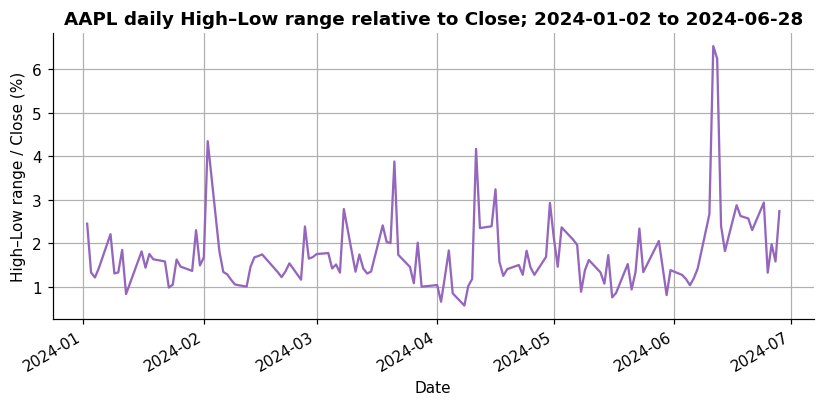

In [23]:
# Purpose: calculate the source-grounded AAPL daily High–Low range ratio.
aapl_real = load_us_daily("AAPL")
real_range_ratio = ((aapl_real["High"] - aapl_real["Low"]) / aapl_real["Close"]).rename("range_ratio")
real_range_summary = pd.Series(
    {
        "symbol": "AAPL",
        "request start (inclusive)": US_HISTORY_REQUEST["start"],
        "request end (exclusive)": US_HISTORY_REQUEST["end"],
        "returned rows": len(aapl_real),
        "High below Low rows": int(aapl_real["High"].lt(aapl_real["Low"]).sum()),
        "negative ratios": int(real_range_ratio.lt(0).sum()),
        "median ratio (%)": 100 * float(real_range_ratio.median()),
        "minimum ratio (%)": 100 * float(real_range_ratio.min()),
        "maximum ratio (%)": 100 * float(real_range_ratio.max()),
    },
    name="AAPL observed result",
)
display(real_range_summary.to_frame().round(4).style.set_caption(
    "AAPL daily High–Low range relative to unadjusted Close for the fixed 2024 request; ratios are derived percentages."
))

ax = (100 * real_range_ratio).plot(color="tab:purple")
ax.set_ylabel("High–Low range / Close (%)")
ax.set_title("AAPL daily High–Low range relative to Close; 2024-01-02 to 2024-06-28")
plt.tight_layout()
plt.show()

assert aapl_real["High"].ge(aapl_real["Low"]).all()
assert real_range_ratio.ge(0).all()


### Interpretation of the source-grounded output

All 124 returned AAPL rows satisfy High greater than or equal to Low, and all 124 derived ratios are nonnegative. The median ratio is 1.4964%, below 2%; the observed minimum is 0.5699% and the maximum is 6.5315%. The output describes only the returned daily fields under the fixed request. It does not identify the intraday price path, tradeable spread, liquidity, or a causal event.


### Discussion questions

1. For High USD 103.00 per share, Low USD 99.00 per share, and Close USD 100.00 per share, derive the ratio. Then keep the USD 4.00 range but change Close to USD 200.00 per share and explain exactly why the ratio changes without claiming that the second session is less risky.
2. A returned row records High USD 98.00 per share, Low USD 95.00 per share, and Close USD 99.00 per share. Decide whether to calculate, clip, or stop. Name the failed OHLC identity and the provider evidence needed before repairing or excluding the row.


## Issue 12 — What does one-session Volume change measure?

One-session Volume change compares the provider's recorded Volume on two consecutive returned rows. Let $V_t$ and $V_{t-1}$ use the same security, provider, session coverage, and unit, with $V_{t-1}>0$. Define

$$
u_t=\frac{V_t}{V_{t-1}}-1.
$$

The result is a decimal relative change. A value of 0.25 means the recorded quantity is 25% larger than on the preceding returned row. The first value is missing because no preceding observation exists. A large change does not by itself establish liquidity, investor attention, news impact, or predictive value.


### Controlled example and prediction

Code 1 uses the artificial Volume values from Issue 5. The values are artificial quantity units and do not represent shares traded on an exchange.

**Prediction before execution.** Predict that exactly one initial value is missing. Using the first two displayed Volume values, predict whether the first available change is positive or negative and calculate it as a percent to four decimal places.


In [24]:
# Purpose: calculate and check one-session Volume change in controlled data.
features["volume_change_1d"] = features["Volume"].pct_change(fill_method=None)

controlled_volume_rows = features[["Volume", "volume_change_1d"]].head(6).copy()
controlled_volume_summary = pd.Series(
    {
        "observations": len(features),
        "initial missing values": int(features["volume_change_1d"].isna().sum()),
        "first available change (%)": 100 * float(features["volume_change_1d"].dropna().iloc[0]),
        "median change (%)": 100 * float(features["volume_change_1d"].median()),
        "minimum change (%)": 100 * float(features["volume_change_1d"].min()),
        "maximum change (%)": 100 * float(features["volume_change_1d"].max()),
    },
    name="Controlled artificial result",
)
display(controlled_volume_rows.round(6).style.set_caption(
    "Artificial Volume and one-session relative change; Volume uses artificial quantity units and change is a decimal value."
))
display(controlled_volume_summary.to_frame().round(4).style.set_caption(
    "Controlled one-session Volume change summary for 90 artificial rows; percentage values equal 100 times the decimal change."
))
assert features["volume_change_1d"].isna().sum() == 1


,Volume,volume_change_1d
Artificial_Date,,
2024-01-02 00:00:00,1104025,nan
2024-01-03 00:00:00,865579,-0.215979
2024-01-04 00:00:00,1014632,0.172200
2024-01-05 00:00:00,1495734,0.474164
2024-01-08 00:00:00,1125176,-0.247743
2024-01-09 00:00:00,948545,-0.156981


,Controlled artificial result
observations,90.000000
initial missing values,1.000000
first available change (%),-21.597900
median change (%),3.822700
minimum change (%),-42.893600
maximum change (%),68.967000


### Interpretation of the controlled output

The 90 artificial Volume observations produce 89 changes and one expected initial missing value. Volume falls from 1,104,025 to 865,579 artificial quantity units, so the first available change is -21.5979%. Across the artificial sample, observed changes range from -42.8936% to 68.9670%. These results show relative changes in the generated values; they do not identify actual trading activity or an economic cause.


### Source-grounded example and prediction

Code 2 calculates one-session changes from the returned AAPL `Volume` column. The comparison is meaningful only if the provider uses a consistent definition and unit across adjacent rows.

#### Source connection

The [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html) documents the daily-history request used here. The returned column name permits the arithmetic, but the cited page does not support a claim that a large change measures investor attention or market liquidity.

**Prediction before execution.** Predict that the AAPL result has one initial missing value. Predict whether the observed changes include both positive and negative values.


,AAPL observed result
symbol,AAPL
request start (inclusive),2024-01-02
request end (exclusive),2024-07-01
returned rows,124
initial missing values,1
positive changes,61
negative changes,62
median change (%),-0.522286
minimum change (%),-66.614848
maximum change (%),180.605878


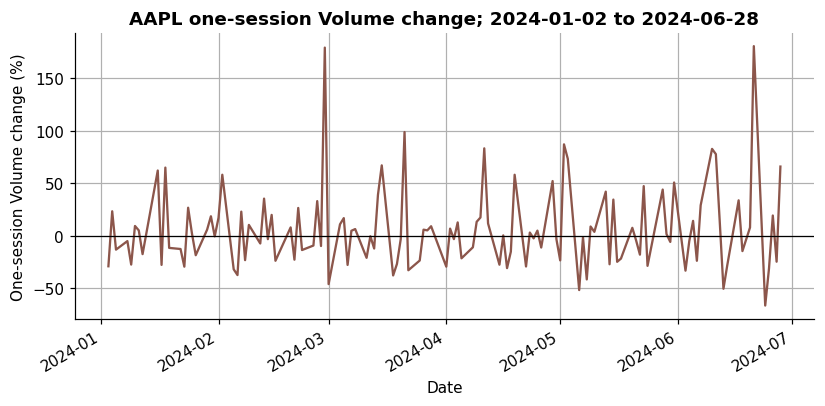

In [25]:
# Purpose: calculate the source-grounded AAPL one-session Volume change.
aapl_real = load_us_daily("AAPL")
real_volume_change = aapl_real["Volume"].pct_change(fill_method=None).rename("volume_change")
real_volume_summary = pd.Series(
    {
        "symbol": "AAPL",
        "request start (inclusive)": US_HISTORY_REQUEST["start"],
        "request end (exclusive)": US_HISTORY_REQUEST["end"],
        "returned rows": len(aapl_real),
        "initial missing values": int(real_volume_change.isna().sum()),
        "positive changes": int(real_volume_change.gt(0).sum()),
        "negative changes": int(real_volume_change.lt(0).sum()),
        "median change (%)": 100 * float(real_volume_change.median()),
        "minimum change (%)": 100 * float(real_volume_change.min()),
        "maximum change (%)": 100 * float(real_volume_change.max()),
    },
    name="AAPL observed result",
)
display(real_volume_summary.to_frame().round(4).style.set_caption(
    "AAPL one-session relative change in returned daily Volume for the fixed 2024 request; changes are derived percentages."
))

ax = (100 * real_volume_change).plot(color="tab:brown")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("One-session Volume change (%)")
ax.set_title("AAPL one-session Volume change; 2024-01-02 to 2024-06-28")
plt.tight_layout()
plt.show()

assert real_volume_change.isna().sum() == 1
assert real_volume_change.gt(0).any() and real_volume_change.lt(0).any()


### Interpretation of the source-grounded output

The 124 returned AAPL rows produce 123 changes and one expected initial missing value. The output contains 61 positive and 62 negative changes. The median is -0.5223%, with observed values from -66.6148% to 180.6059%. The wide range makes the provider's unit and session coverage important; it does not establish why Volume changed or whether the change predicts a return.


### Discussion questions

1. A provider records 1,000,000 shares on one day but changes its display unit without warning and records the next day's 1,200 thousand shares as the number 1,200. Calculate the apparent relative change from those stored numbers, identify the unit discontinuity, and state the conversion required before calculation.
2. An AAPL row shows a 100% increase in returned Volume and a positive same-day return. Decide whether these two observations establish that news caused buying pressure. Specify at least two additional pieces of evidence and one comparison period needed before making a narrower empirical claim.


## Issue 13 — How is a next-session target aligned without entering the time-$t$ feature set?

A target is the later outcome that a model will attempt to predict or explain. Let $P_t$ and $P_{t+1}$ be closing prices in the same currency and field convention. The next-session simple-return target stored on row $t$ is

$$
y_t=\frac{P_{t+1}}{P_t}-1.
$$

The value belongs to the interval from $t$ to $t+1$ and becomes observable only when $P_{t+1}$ is available. In pandas, `return_1d.shift(-1)` places the return ending on the next returned row onto row $t$. That storage convention is useful for supervised learning, but it does not make $y_t$ a time-$t$ feature. A negative shift therefore requires an explicit role check, not merely a missing-value check.


### Controlled example and prediction

Code 1 constructs a two-session momentum feature and a next-session target from six artificial closing prices. It records the source endpoint of the target beside the row on which the value is stored.

**Prediction before execution.** Predict the target stored on 2026-02-02, the date on which that target first becomes observable, and why the final target must be missing. Predict whether the target appears in the explicit feature list.


In [26]:
# Purpose: align a controlled next-session target and keep it out of the feature list.
target_demo = pd.DataFrame(
    {"Close": [100.0, 102.0, 101.0, 104.0, 103.0, 105.0]},
    index=pd.bdate_range("2026-02-02", periods=6),
)
target_demo.index.name = "Artificial_Date"
target_demo["momentum_2_feature"] = target_demo["Close"] / target_demo["Close"].shift(2) - 1
target_demo["return_1d"] = target_demo["Close"].pct_change(fill_method=None)
target_demo["next_return_target"] = target_demo["return_1d"].shift(-1)
target_demo["target_source_end_date"] = target_demo.index.to_series().shift(-1)

allowed_controlled_features = ["momentum_2_feature"]
controlled_role_table = pd.DataFrame(
    {
        "role": ["feature available after Close[t] is available", "future outcome available after Close[t+1]"],
        "allowed in time-t feature list": [True, False],
        "first or final missing count": [
            int(target_demo["momentum_2_feature"].isna().sum()),
            int(target_demo["next_return_target"].isna().sum()),
        ],
    },
    index=["momentum_2_feature", "next_return_target"],
)
display(target_demo.round(6).style.set_caption(
    "Artificial prices, two-session momentum feature, and next-session target; returns are decimal values and the target source end date is explicit."
))
display(controlled_role_table.style.set_caption(
    "Role and availability of the controlled feature and target under the row-t storage convention."
))

assert np.isclose(target_demo.loc[pd.Timestamp("2026-02-02"), "next_return_target"], 0.02)
assert pd.isna(target_demo["next_return_target"].iloc[-1])
assert "next_return_target" not in allowed_controlled_features


,Close,momentum_2_feature,return_1d,next_return_target,target_source_end_date
Artificial_Date,,,,,
2026-02-02 00:00:00,100.000000,nan,nan,0.020000,2026-02-03 00:00:00
2026-02-03 00:00:00,102.000000,nan,0.020000,-0.009804,2026-02-04 00:00:00
2026-02-04 00:00:00,101.000000,0.010000,-0.009804,0.029703,2026-02-05 00:00:00
2026-02-05 00:00:00,104.000000,0.019608,0.029703,-0.009615,2026-02-06 00:00:00
2026-02-06 00:00:00,103.000000,0.019802,-0.009615,0.019417,2026-02-09 00:00:00
2026-02-09 00:00:00,105.000000,0.009615,0.019417,nan,NaT


,role,allowed in time-t feature list,first or final missing count
momentum_2_feature,feature available after Close[t] is available,True,2
next_return_target,future outcome available after Close[t+1],False,1


### Interpretation of the controlled output

The target stored on 2026-02-02 is 0.020000, the 2.00% return from the 2026-02-02 Close of 100.0 to the 2026-02-03 Close of 102.0 artificial price units. Its recorded source end date is 2026-02-03, so it is not available to a 2026-02-02 decision. The 2026-02-09 target is missing because there is no later price. The role table excludes `next_return_target` from the time-$t$ feature list even though it is numeric.


### Source-grounded example and prediction

Code 2 creates an AAPL five-session momentum feature and a next-session return target. It displays target source dates across a weekend and checks the feature and target roles separately.

#### Source connection

Pandas documents [`shift`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html) as moving stored values by periods and [`pct_change`](https://pandas.pydata.org/docs/reference/api/pandas.Series.pct_change.html) as fractional change. The [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html) documents the request interface. None of these operations changes when a later market value became observable.

**Prediction before execution.** Predict five initial missing momentum values, one final missing target, and a displayed target whose source end date follows a multi-day calendar gap while remaining the next returned row.


In [27]:
# Purpose: align an AAPL next-session target and document its source endpoint.
aapl_real = load_us_daily("AAPL")
real_target_data = pd.DataFrame(index=aapl_real.index)
real_target_data["momentum_5_feature"] = aapl_real["Close"] / aapl_real["Close"].shift(5) - 1
real_target_data["return_1d"] = aapl_real["Close"].pct_change(fill_method=None)
real_target_data["next_return_target"] = real_target_data["return_1d"].shift(-1)
real_target_data["target_source_end_date"] = real_target_data.index.to_series().shift(-1)

sample_start = pd.Timestamp("2024-01-11")
sample_end = pd.Timestamp("2024-01-17")
real_target_sample = real_target_data.loc[sample_start:sample_end, [
    "momentum_5_feature", "next_return_target", "target_source_end_date"
]]
real_role_record = pd.DataFrame(
    {
        "role": ["time-t feature after Close[t] is available", "future outcome after the next returned Close"],
        "allowed in time-t feature list": [True, False],
        "missing values": [
            int(real_target_data["momentum_5_feature"].isna().sum()),
            int(real_target_data["next_return_target"].isna().sum()),
        ],
        "first or last affected date": [
            str(real_target_data["momentum_5_feature"].first_valid_index().date()),
            str(real_target_data.index[-1].date()),
        ],
    },
    index=["momentum_5_feature", "next_return_target"],
)
display(real_target_sample.round(6).style.set_caption(
    "AAPL five-session momentum and next-session target around the January 2024 weekend and holiday; returns are decimal values."
))
display(real_role_record.style.set_caption(
    "AAPL feature and target roles under the fixed daily request and row-t target storage convention."
))

allowed_real_features = ["momentum_5_feature"]
assert real_target_data["momentum_5_feature"].isna().sum() == 5
assert real_target_data["next_return_target"].isna().sum() == 1
assert "next_return_target" not in allowed_real_features


,momentum_5_feature,next_return_target,target_source_end_date
Date,,,
2024-01-11 00:00:00,0.020230,0.001778,2024-01-12 00:00:00
2024-01-12 00:00:00,0.026162,-0.012317,2024-01-16 00:00:00
2024-01-16 00:00:00,-0.010401,-0.005174,2024-01-17 00:00:00
2024-01-17 00:00:00,-0.013287,0.032571,2024-01-18 00:00:00


,role,allowed in time-t feature list,missing values,first or last affected date
momentum_5_feature,time-t feature after Close[t] is available,True,5,2024-01-09
next_return_target,future outcome after the next returned Close,False,1,2024-06-28


### Interpretation of the source-grounded output

The AAPL role table records five initial missing momentum values and one final missing target on 2024-06-28. In the displayed sample, the target stored on Friday 2024-01-12 uses Tuesday 2024-01-16 as its source end date because the next returned daily row follows a four-calendar-day gap. It is still one returned-row ahead, not one calendar day ahead. The explicit feature list contains momentum only; a numeric-column selector would not enforce this boundary.


### Discussion questions

1. A feature row is dated April 2 and its next-session target uses a return ending April 3. State the two price endpoints, the row on which the target may be stored, when the target first becomes observable, and when it may enter a chronological training sample.
2. A team drops rows with missing values and then selects every remaining numeric column, including `next_return_target`, as model input. Explain why the missing-value check does not detect this leakage and write an explicit allow-list or role check that would stop it.


## Issue 14 — Why can a centered window leak future values?


A trailing rolling window labels its result at the right endpoint when `center=False`. A centered window labels the result near the middle and can therefore include later observations relative to the labeled row. Centered smoothing can be useful for retrospective description but is invalid as a real-time feature when it uses future rows.

The example changes one later price. A valid trailing value at an earlier date remains unchanged, while a centered value near that date changes because the future price entered its window.


### Controlled example and prediction

Code 1 changes one later artificial price and compares the effect on a trailing three-price mean and a centered three-price mean at an earlier date.

**Prediction before execution.** Predict which artificial mean changes after the later price is altered and the two values before and after the change.


,Price_original,Trailing_3_original,Centered_3_original,Price_changed,Trailing_3_changed,Centered_3_changed
2026-03-01,100.0,NaN,NaN,100.0,NaN,NaN
2026-03-02,101.0,NaN,101.0,101.0,NaN,101.0
2026-03-03,102.0,101.0,102.0,102.0,101.0,102.0
2026-03-04,103.0,102.0,103.0,103.0,102.0,115.0
2026-03-05,104.0,103.0,104.0,140.0,115.0,116.0
2026-03-06,105.0,104.0,105.0,105.0,116.0,117.0
2026-03-07,106.0,105.0,NaN,106.0,117.0,NaN


,Original,After_later_price_change,Changed
Trailing mean at comparison date,102.0,102.0,False
Centered mean at comparison date,103.0,115.0,True


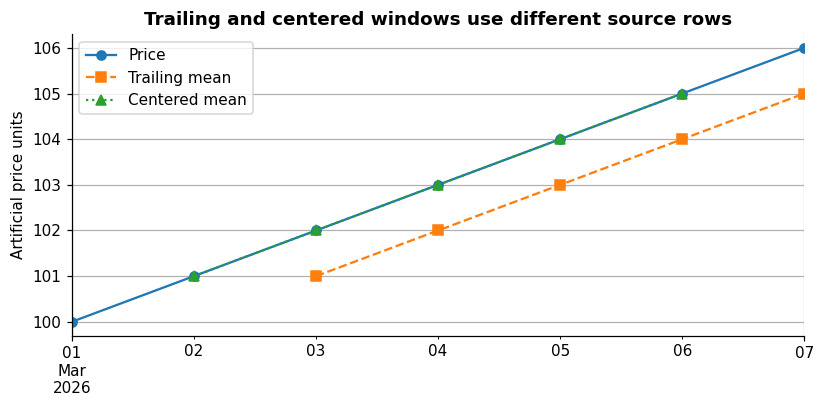

In [28]:
# Purpose: calculate the controlled example for Issue 14.
window_demo = pd.Series(
    [100.0, 101.0, 102.0, 103.0, 104.0, 105.0, 106.0],
    index=pd.date_range("2026-03-01", periods=7, freq="D"),
    name="Price",
)
window_changed = window_demo.copy()
window_changed.iloc[4] = 140.0

window_comparison = pd.DataFrame(
    {
        "Price_original": window_demo,
        "Trailing_3_original": window_demo.rolling(3, center=False).mean(),
        "Centered_3_original": window_demo.rolling(3, center=True).mean(),
        "Price_changed": window_changed,
        "Trailing_3_changed": window_changed.rolling(3, center=False).mean(),
        "Centered_3_changed": window_changed.rolling(3, center=True).mean(),
    }
)
display(window_comparison.round(4))

comparison_date = window_demo.index[3]
effect_table = pd.DataFrame(
    {
        "Original": [window_comparison.loc[comparison_date, "Trailing_3_original"], window_comparison.loc[comparison_date, "Centered_3_original"]],
        "After_later_price_change": [window_comparison.loc[comparison_date, "Trailing_3_changed"], window_comparison.loc[comparison_date, "Centered_3_changed"]],
    },
    index=["Trailing mean at comparison date", "Centered mean at comparison date"],
)
effect_table["Changed"] = ~np.isclose(effect_table["Original"], effect_table["After_later_price_change"])
display(effect_table)

ax = window_comparison[["Price_original", "Trailing_3_original", "Centered_3_original"]].plot(style=["o-", "s--", "^:"])
ax.set_ylabel("Artificial price units")
ax.set_title("Trailing and centered windows use different source rows")
ax.legend(["Price", "Trailing mean", "Centered mean"])
plt.tight_layout()
plt.show()

assert not effect_table.loc["Trailing mean at comparison date", "Changed"]
assert effect_table.loc["Centered mean at comparison date", "Changed"]

### Interpretation of the controlled output


At 2026-03-04, changing the later 2026-03-05 price from 104.0 to 140.0 leaves the trailing mean at 102.0 but changes the centered mean from 103.0 to 115.0. This directly shows that the centered value uses a later observation. A smoother curve does not repair that information error.


### Source-grounded example and prediction

Code 2 performs a prefix test on AAPL Close. It calculates a trailing and centered five-price mean on the full response, recalculates both after cutting the data at a selected date, and compares overlapping values. A valid time-$t$ feature must not change merely because later rows are added.

#### Source connection

Pandas documents the `center` setting for rolling windows. A centered result may be useful for retrospective description, but an official timestamp on each price does not make future rows available to a historical trading decision.

Sources: [pandas rolling-window documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html); [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html).

**Prediction before execution.** Predict whether the trailing AAPL prefix values remain identical and how many centered values appear only after later rows are added.


In [29]:
# Purpose: calculate the source-grounded example for Issue 14.
aapl_real = load_us_daily("AAPL")
real_close = aapl_real["Close"]
cutoff_position = 60
real_prefix = real_close.iloc[:cutoff_position]
full_trailing = real_close.rolling(5, min_periods=5).mean()
prefix_trailing = real_prefix.rolling(5, min_periods=5).mean()
full_centered = real_close.rolling(5, min_periods=5, center=True).mean()
prefix_centered = real_prefix.rolling(5, min_periods=5, center=True).mean()
common_dates = real_prefix.index
trailing_difference = (full_trailing.loc[common_dates] - prefix_trailing).abs().dropna()
centered_difference = (full_centered.loc[common_dates] - prefix_centered).abs().dropna()
centered_available_only_with_later_rows = (
    full_centered.loc[common_dates].notna() & prefix_centered.isna()
)
real_prefix_test = pd.Series(
    {
        "cutoff date": str(real_prefix.index[-1].date()),
        "maximum trailing difference on common dates (USD)": float(trailing_difference.max()),
        "maximum centered difference on common dates (USD)": float(centered_difference.max()),
        "centered values available only after later rows are added": int(centered_available_only_with_later_rows.sum()),
    },
    name="Observed result",
)
display(real_prefix_test.to_frame())
assert np.isclose(trailing_difference.max(), 0)
assert centered_available_only_with_later_rows.any()

,Observed result
cutoff date,2024-03-27
maximum trailing difference on common dates (USD),0.0
maximum centered difference on common dates (USD),0.0
centered values available only after later rows are added,2


### Interpretation of the source-grounded output


At the 2024-03-27 cutoff, the maximum trailing-mean difference on common valid dates is 0.0 USD. Two centered values are unavailable in the historical prefix but appear after later rows are added to the full response. The prefix test therefore locates future dependence directly instead of judging the feature by appearance.


### Discussion questions

1. At the comparison date, list the three source prices used by the trailing mean and by the centered mean. Identify the later source row in the centered result and explain why a timestamp on the output row does not make that source available.
2. Design a prefix test for the feature: specify the cutoff, the overlapping dates to compare, and the expected result for a valid trailing feature. Explain what a changed historical value proves about future dependence.


## Issue 15 — When does preprocessing use unavailable rows?


A valid trailing feature can become invalid when preprocessing parameters are estimated with later observations. For feature value $x_t$, a standardized value has the form

$$
z_t=\frac{x_t-\widehat{\mu}_{\mathcal{T}}}{\widehat{\sigma}_{\mathcal{T}}},
$$

where $\mathcal{T}$ is the set of rows used to estimate the mean and standard deviation. If $\mathcal{T}$ includes rows later than the decision being represented, then the transformed historical value depends on unavailable observations. Standardizing with the full dataset therefore violates the information boundary even when the original feature is trailing.

The example separates a development segment from a later segment. It compares parameters fitted only on the development rows with parameters fitted on all rows. This illustrates the boundary; Week 5 will place preprocessing inside chronological model estimation.


### Controlled example and prediction

Code 1 standardizes the same early artificial momentum values using parameters estimated from development rows and, deliberately incorrectly, from the full sample.

**Prediction before execution.** Predict whether fitting standardization on later artificial rows changes earlier transformed values.


In [30]:
# Purpose: calculate the controlled example for Issue 15.
scaling_source = features["mom_5"].dropna().copy()
development_size = 55
development_values = scaling_source.iloc[:development_size]

development_mean = development_values.mean()
development_std = development_values.std(ddof=1)
full_mean = scaling_source.mean()
full_std = scaling_source.std(ddof=1)

features.loc[scaling_source.index, "mom_5_z_development_fit"] = (
    scaling_source - development_mean
) / development_std
features.loc[scaling_source.index, "mom_5_z_full_fit_invalid"] = (
    scaling_source - full_mean
) / full_std

parameter_table = pd.DataFrame(
    {
        "Fit_rows": [development_size, len(scaling_source)],
        "Mean": [development_mean, full_mean],
        "Standard_deviation": [development_std, full_std],
        "Permitted_for_development_rows": [True, False],
    },
    index=["Development-only fit", "Full-data fit"],
)
display(parameter_table.round(6))
display(
    features[["mom_5", "mom_5_z_development_fit", "mom_5_z_full_fit_invalid"]]
    .loc[scaling_source.index[:5]]
    .round(6)
)

parameter_difference = pd.Series(
    {
        "absolute_mean_difference": abs(development_mean - full_mean),
        "absolute_std_difference": abs(development_std - full_std),
        "maximum_transformed_difference_on_development_rows": (
            features.loc[development_values.index, "mom_5_z_development_fit"]
            - features.loc[development_values.index, "mom_5_z_full_fit_invalid"]
        ).abs().max(),
    },
    name="Difference",
)
display(parameter_difference.rename_axis("Check").to_frame())
assert parameter_difference["maximum_transformed_difference_on_development_rows"] > 0

,Fit_rows,Mean,Standard_deviation,Permitted_for_development_rows
Development-only fit,55,0.017468,0.030663,True
Full-data fit,85,0.008758,0.031158,False


,mom_5,mom_5_z_development_fit,mom_5_z_full_fit_invalid
Artificial_Date,,,
2024-01-09,0.002037,-0.503246,-0.215691
2024-01-10,-0.004585,-0.719197,-0.428215
2024-01-11,0.022046,0.149296,0.426498
2024-01-12,0.001847,-0.509438,-0.221784
2024-01-15,-0.008489,-0.846514,-0.553513


,Difference
Check,
absolute_mean_difference,0.008711
absolute_std_difference,0.000494
maximum_transformed_difference_on_development_rows,0.300219


### Interpretation of the controlled output


The development-only fit uses 55 rows, mean 0.017468, and standard deviation 0.030663; the full-data fit uses 85 rows, mean 0.008758, and standard deviation 0.031158. The maximum difference between the two transformations on development rows is 0.300219. The momentum formula remains trailing; the information error enters through parameter estimation.


### Source-grounded example and prediction

Code 2 standardizes AAPL five-session momentum in two ways. One set of parameters is estimated only from the first 60 valid observations; the other is estimated from all valid observations. Comparing the same early rows isolates the information added by later observations.

#### Source connection

White (2000) explains the problem created when the same data are reused for model selection and evaluation. Full-sample standardization is a simpler boundary failure: later rows change parameters applied to earlier rows before a model is even fitted.

Sources: [White (2000)](https://doi.org/10.1111/1468-0262.00152); [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html).

**Prediction before execution.** Predict whether the AAPL development-only and full-response parameters differ and whether the transformed-value difference is positive.


In [31]:
# Purpose: calculate the source-grounded example for Issue 15.
aapl_real = load_us_daily("AAPL")
real_mom = (aapl_real["Close"] / aapl_real["Close"].shift(5) - 1).dropna()
real_development = real_mom.iloc[:60]
development_mean, development_std = real_development.mean(), real_development.std(ddof=1)
full_mean, full_std = real_mom.mean(), real_mom.std(ddof=1)
z_development_fit = (real_development - development_mean) / development_std
z_full_fit = (real_development - full_mean) / full_std
real_scaling_record = pd.DataFrame(
    {
        "Fit rows": [len(real_development), len(real_mom)],
        "Mean": [development_mean, full_mean],
        "Standard deviation": [development_std, full_std],
        "Permitted for the first 60 valid rows": [True, False],
    },
    index=["development-only fit", "full-response fit"],
)
real_scaling_difference = pd.Series(
    {"maximum absolute transformed difference": float((z_development_fit - z_full_fit).abs().max()), "mean absolute transformed difference": float((z_development_fit - z_full_fit).abs().mean())},
    name="Observed result",
)
display(real_scaling_record.round(6))
display(real_scaling_difference.to_frame().round(6))
assert real_scaling_difference["maximum absolute transformed difference"] > 0

,Fit rows,Mean,Standard deviation,Permitted for the first 60 valid rows
development-only fit,60,-0.006145,0.028752,True
full-response fit,119,0.006446,0.035152,False


,Observed result
maximum absolute transformed difference,0.806843
mean absolute transformed difference,0.360981


### Interpretation of the source-grounded output


The development-only AAPL fit uses 60 rows, mean -0.006145, and standard deviation 0.028752; the full-response fit uses 119 rows, mean 0.006446, and standard deviation 0.035152. On the same first 60 transformed observations, the maximum absolute difference is 0.806843 and the mean absolute difference is 0.360981. The raw momentum is trailing; the unavailable information enters through the full-response parameters.


### Discussion questions

1. A scaler is fitted on January–December and applied to a March prediction. Identify the unavailable rows that influence the March standardized value and state which parameters must instead be fitted using the permitted March training window.
2. Development-only and full-sample standardized values have the same sign but different magnitudes. Decide whether the full-sample version is acceptable because the later signal is unchanged, and defend the answer using the information boundary rather than performance.


## Issue 16 — How should a signal rule treat unavailable feature history?

A signal is the output of a stated rule after every required feature is available. For five-session momentum $m_t^{(5)}$, this classroom rule is

$$
s_t=
\begin{cases}
1, & m_t^{(5)}>0,\\
0, & m_t^{(5)}\le 0,\\
\text{missing}, & m_t^{(5)}\text{ is unavailable}.
\end{cases}
$$

A calculated momentum of zero is a valid nonpositive value. Missing early history means that the required six price endpoints do not exist. Replacing missing momentum with zero before applying the rule silently creates signal observations on dates when the feature was unavailable. The output remains a signal; Week 4 must still define the position, execution time, and eligible return interval.


### Controlled example and prediction

Code 1 applies the stated rule to the artificial five-session momentum from Issue 9. It compares the result that keeps unavailable history missing with a deliberately invalid calculation that fills missing momentum with zero first.

**Prediction before execution.** Predict the counts of signal 1, signal 0, and missing under the stated rule. Predict how many early signal observations the zero-filled calculation creates.


,Close,mom_5,signal_at_close
Artificial_Date,,,
2024-01-02 00:00:00,99.072580,nan,nan
2024-01-03 00:00:00,99.378876,nan,nan
2024-01-04 00:00:00,97.162385,nan,nan
2024-01-05 00:00:00,98.823251,nan,nan
2024-01-08 00:00:00,99.603017,nan,nan
2024-01-09 00:00:00,99.274415,0.002037,1.000000
2024-01-10 00:00:00,98.923269,-0.004585,0.000000
2024-01-11 00:00:00,99.304463,0.022046,1.000000
2024-01-12 00:00:00,99.005816,0.001847,1.000000


,signal 1,signal 0,signal missing,signals created before momentum exists
Preserve unavailable history,52,33,5,0
Fill missing momentum with zero first,52,38,0,5


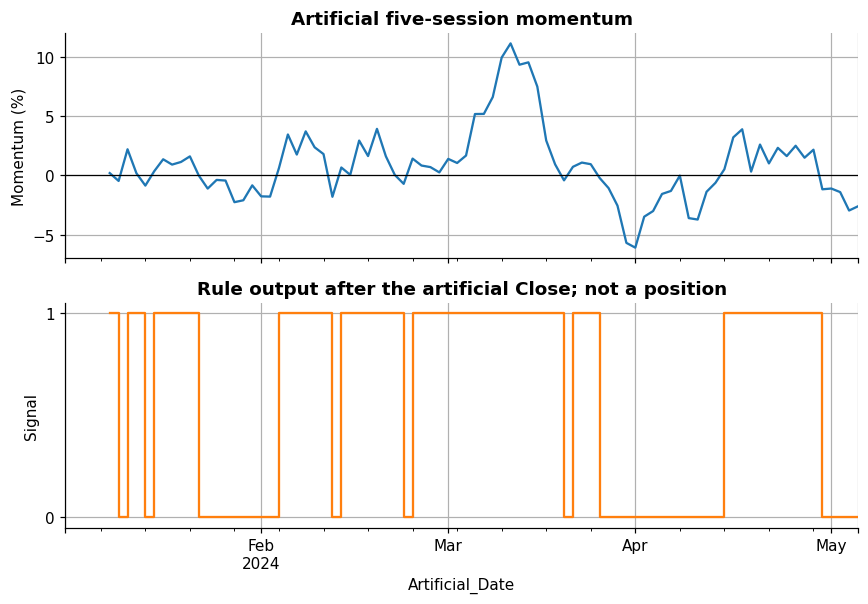

In [32]:
# Purpose: apply the controlled signal rule while preserving unavailable history.
features["signal_at_close"] = np.where(
    features["mom_5"].isna(),
    np.nan,
    np.where(features["mom_5"] > 0, 1.0, 0.0),
)
invalid_signal_after_zero_fill = (features["mom_5"].fillna(0.0) > 0).astype(float)

controlled_signal_rows = features[["Close", "mom_5", "signal_at_close"]].head(10).copy()
controlled_signal_counts = pd.DataFrame(
    {
        "signal 1": [int(features["signal_at_close"].eq(1).sum()), int(invalid_signal_after_zero_fill.eq(1).sum())],
        "signal 0": [int(features["signal_at_close"].eq(0).sum()), int(invalid_signal_after_zero_fill.eq(0).sum())],
        "signal missing": [int(features["signal_at_close"].isna().sum()), int(invalid_signal_after_zero_fill.isna().sum())],
        "signals created before momentum exists": [0, int(features["mom_5"].isna().sum())],
    },
    index=["Preserve unavailable history", "Fill missing momentum with zero first"],
)
display(controlled_signal_rows.round(6).style.set_caption(
    "Artificial closing price, five-session momentum, and binary signal that keeps unavailable history missing; momentum is a decimal return."
))
display(controlled_signal_counts.style.set_caption(
    "Controlled signal counts under the stated rule and the deliberately invalid zero-fill calculation."
))

fig, axes = plt.subplots(2, 1, figsize=(8.0, 5.6), sharex=True)
(100 * features["mom_5"]).plot(ax=axes[0], color="tab:blue")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Momentum (%)")
axes[0].set_title("Artificial five-session momentum")
features["signal_at_close"].plot(ax=axes[1], drawstyle="steps-post", color="tab:orange")
axes[1].set_yticks([0, 1], ["0", "1"])
axes[1].set_ylabel("Signal")
axes[1].set_title("Rule output after the artificial Close; not a position")
plt.tight_layout()
plt.show()

assert features["signal_at_close"].isna().equals(features["mom_5"].isna())
assert set(features["signal_at_close"].dropna().unique()).issubset({0.0, 1.0})


### Interpretation of the controlled output

The 90 artificial rows contain 52 signal-1 observations, 33 signal-0 observations, and five missing signals. Those five missing values match the unavailable five-session momentum history. Filling momentum with zero first creates five additional signal-0 observations, even though the required source prices do not exist. The figure displays the feature and rule output only; it contains no position or strategy return.


### Source-grounded example and prediction

Code 2 applies the same rule to AAPL five-session momentum and compares a valid value close to zero with the five unavailable initial values.

#### Source connection

NumPy documents [`where`](https://numpy.org/doc/stable/reference/generated/numpy.where.html) for conditional selection, and pandas documents [`shift`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html) for the lag used in momentum. The [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html) documents the input request. The binary threshold and missing-history policy are classroom decisions, not provider facts.

**Prediction before execution.** Predict five missing AAPL signals under the stated rule and none after zero filling. Predict whether the valid momentum closest to zero is treated as missing.


,AAPL observed result
returned rows,124
signal 1,65
signal 0,54
signal missing,5
missing after zero fill,0
valid momentum closest to zero date,2024-04-03
valid momentum closest to zero (%),-0.035362
signal at that valid date,0


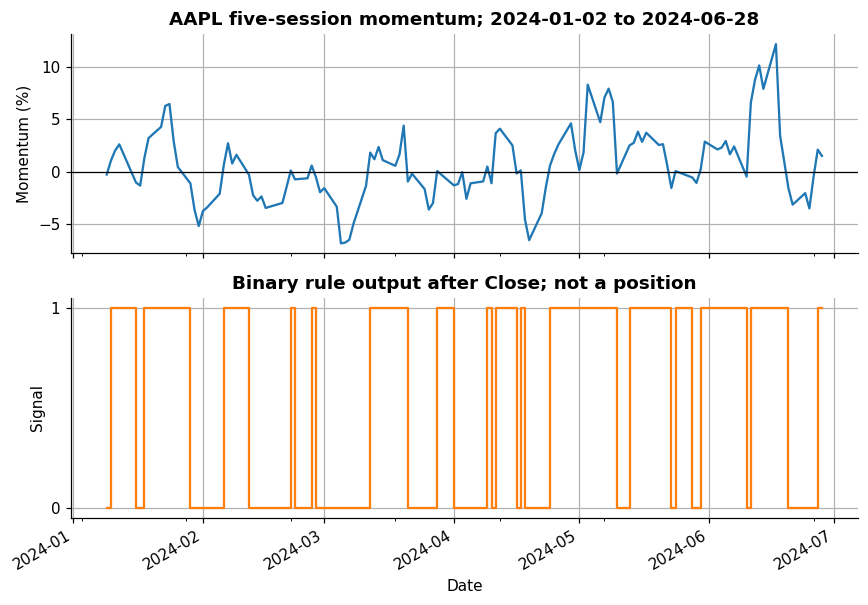

In [33]:
# Purpose: apply the source-grounded AAPL signal rule while preserving unavailable history.
aapl_real = load_us_daily("AAPL")
real_mom_5 = aapl_real["Close"] / aapl_real["Close"].shift(5) - 1
real_signal = pd.Series(
    np.where(real_mom_5.isna(), np.nan, np.where(real_mom_5 > 0, 1.0, 0.0)),
    index=real_mom_5.index,
    name="signal_after_close",
)
invalid_real_signal = (real_mom_5.fillna(0.0) > 0).astype(float)
closest_zero_date = real_mom_5.dropna().abs().idxmin()

real_signal_summary = pd.Series(
    {
        "returned rows": len(real_signal),
        "signal 1": int(real_signal.eq(1).sum()),
        "signal 0": int(real_signal.eq(0).sum()),
        "signal missing": int(real_signal.isna().sum()),
        "missing after zero fill": int(invalid_real_signal.isna().sum()),
        "valid momentum closest to zero date": str(closest_zero_date.date()),
        "valid momentum closest to zero (%)": 100 * float(real_mom_5.loc[closest_zero_date]),
        "signal at that valid date": int(real_signal.loc[closest_zero_date]),
    },
    name="AAPL observed result",
)
display(real_signal_summary.to_frame().round(6).style.set_caption(
    "AAPL five-session momentum signal counts and the valid momentum observation closest to zero under the fixed 2024 request."
))

fig, axes = plt.subplots(2, 1, figsize=(8.0, 5.6), sharex=True)
(100 * real_mom_5).plot(ax=axes[0], color="tab:blue")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Momentum (%)")
axes[0].set_title("AAPL five-session momentum; 2024-01-02 to 2024-06-28")
real_signal.plot(ax=axes[1], drawstyle="steps-post", color="tab:orange")
axes[1].set_yticks([0, 1], ["0", "1"])
axes[1].set_ylabel("Signal")
axes[1].set_title("Binary rule output after Close; not a position")
plt.tight_layout()
plt.show()

assert real_signal.isna().sum() == 5
assert invalid_real_signal.isna().sum() == 0
assert set(real_signal.dropna().unique()).issubset({0.0, 1.0})


### Interpretation of the source-grounded output

The 124 AAPL rows reconcile into 65 signal-1 observations, 54 signal-0 observations, and five missing initial signals. Zero filling reduces the missing count to zero and therefore creates five rule outputs before the feature exists. The valid momentum closest to zero is -0.035362% on 2024-04-03; it produces signal 0 and is not missing. The output establishes the stated mapping only, not an executable position or investment performance.


### Discussion questions

1. Apply the stated rule to four cases: momentum +0.5%, exactly 0.0%, -0.5%, and unavailable history. Give the signal for each case and explain why the fourth case cannot be grouped with signal 0 without changing the historical decision record.
2. A team wants a signal before its twenty-session volatility input exists. Compare three choices: leave the signal missing, replace the feature with a shorter prespecified lookback, or impute a volatility value. Identify which choices change the strategy definition and state what must be fixed before evaluation.


## Issue 17 — How is a separately published value aligned?


A variable can describe an earlier period but remain unavailable until its publication time. If releases have publication times $\tau_1,\ldots,\tau_J$, then the release eligible for decision time $t$ is indexed by

$$
j^*(t)=\max\{j:\tau_j\le t\}.
$$

If that set is empty, the aligned value must remain missing. Joining on the period-end label instead would place a value into decisions that occurred before release.

`pandas.merge_asof` requires sorted keys. A backward search implements the stated no-later-than rule in this artificial example.


### Controlled example and prediction

Code 1 aligns four artificial decision times with one separately published value using a backward no-later-than join.

**Prediction before execution.** Predict which artificial decisions remain unmatched before the 08:00 release and which receive 1.20 afterward.


,decision_time
0,2026-04-02 16:05:00
1,2026-04-03 07:30:00
2,2026-04-03 16:05:00
3,2026-04-06 16:05:00


,period_end,publication_time,indicator_value
0,2026-03-31,2026-04-03 08:00:00,1.2


,decision_time,period_end,publication_time,indicator_value,release_available
0,2026-04-02 16:05:00,NaT,NaT,NaN,False
1,2026-04-03 07:30:00,NaT,NaT,NaN,False
2,2026-04-03 16:05:00,2026-03-31,2026-04-03 08:00:00,1.2,True
3,2026-04-06 16:05:00,2026-03-31,2026-04-03 08:00:00,1.2,True


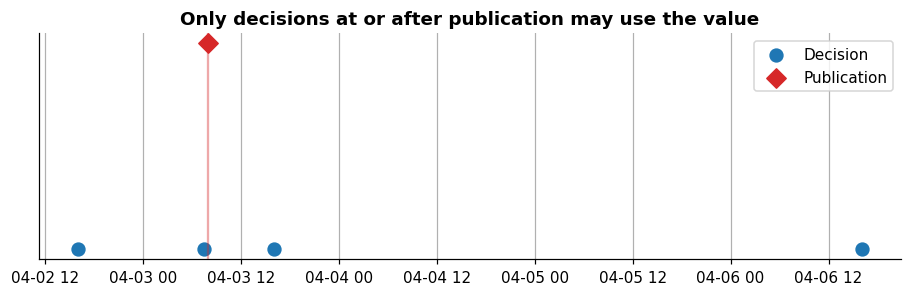

In [34]:
# Purpose: calculate the controlled example for Issue 17.
decisions = pd.DataFrame(
    {
        "decision_time": pd.to_datetime(
            [
                "2026-04-02 16:05", "2026-04-03 07:30",
                "2026-04-03 16:05", "2026-04-06 16:05",
            ]
        )
    }
).sort_values("decision_time")

releases = pd.DataFrame(
    {
        "period_end": pd.to_datetime(["2026-03-31"]),
        "publication_time": pd.to_datetime(["2026-04-03 08:00"]),
        "indicator_value": [1.20],
    }
).sort_values("publication_time")

aligned_release = pd.merge_asof(
    decisions,
    releases,
    left_on="decision_time",
    right_on="publication_time",
    direction="backward",
)
aligned_release["release_available"] = aligned_release["indicator_value"].notna()
display(decisions)
display(releases)
display(aligned_release)

fig, ax = plt.subplots(figsize=(8.4, 2.8))
ax.scatter(decisions["decision_time"], np.zeros(len(decisions)), marker="o", s=70, label="Decision")
ax.scatter(releases["publication_time"], [0.12], marker="D", s=80, color="tab:red", label="Publication")
ax.axvline(releases["publication_time"].iloc[0], color="tab:red", alpha=0.4)
ax.set_yticks([])
ax.set_title("Only decisions at or after publication may use the value")
ax.legend()
plt.tight_layout()
plt.show()

matched = aligned_release["publication_time"].notna()
assert aligned_release.loc[:1, "indicator_value"].isna().all()
assert aligned_release.loc[2:, "indicator_value"].eq(1.20).all()
assert (aligned_release.loc[matched, "publication_time"] <= aligned_release.loc[matched, "decision_time"]).all()

### Interpretation of the controlled output


The April 2 and April 3 07:30 decisions remain unmatched. The two later decisions receive 1.20 because publication occurred at 08:00. The period-end date does not control availability. The figure makes the release boundary visible without implying a real publication schedule.


### Source-grounded example and prediction

The [SEC filing page for Apple's Form 10-Q](https://www.sec.gov/Archives/edgar/data/320193/000032019324000006/0000320193-24-000006-index.htm) reports a period of report of 2023-12-30, an accepted timestamp of 2024-02-01 18:03:38, and a filing date of 2024-02-02. Code 2 uses those displayed SEC fields and aligns the filing to three hypothetical research decision times. The example does not claim that the accepted timestamp equals a tradable dissemination time.

#### Source connection

The SEC filing page for Apple's fiscal 2024 first-quarter Form 10-Q separately reports its period of report, filing date, and accepted timestamp. Pandas documents that a backward `merge_asof` selects the latest key no later than each decision key when both inputs are sorted.

Sources: [SEC Apple Form 10-Q filing page](https://www.sec.gov/Archives/edgar/data/320193/000032019324000006/0000320193-24-000006-index.htm); [pandas as-of merge documentation](https://pandas.pydata.org/docs/reference/api/pandas.merge_asof.html).

**Prediction before execution.** Predict which of the three decisions match Apple's SEC filing under the displayed accepted-time rule.


In [35]:
# Purpose: calculate the source-grounded example for Issue 17.
sec_filing = pd.DataFrame(
    {
        "period_of_report": pd.to_datetime(["2023-12-30"]),
        "accepted_time_as_displayed": pd.to_datetime(["2024-02-01 18:03:38"]),
        "filing_date": pd.to_datetime(["2024-02-02"]),
        "form": ["10-Q"],
        "accession_number": ["0000320193-24-000006"],
    }
).sort_values("accepted_time_as_displayed")
sec_decisions = pd.DataFrame(
    {"decision_time_as_displayed": pd.to_datetime(["2024-02-01 16:00:00", "2024-02-01 18:30:00", "2024-02-02 10:00:00"])}
).sort_values("decision_time_as_displayed")
sec_aligned = pd.merge_asof(
    sec_decisions, sec_filing,
    left_on="decision_time_as_displayed", right_on="accepted_time_as_displayed",
    direction="backward",
)
sec_aligned["filing_available_under_stated_rule"] = sec_aligned["accession_number"].notna()
display(sec_filing)
display(sec_aligned)
assert sec_aligned["filing_available_under_stated_rule"].tolist() == [False, True, True]

,period_of_report,accepted_time_as_displayed,filing_date,form,accession_number
0,2023-12-30,2024-02-01 18:03:38,2024-02-02,10-Q,0000320193-24-000006


,decision_time_as_displayed,period_of_report,accepted_time_as_displayed,filing_date,form,accession_number,filing_available_under_stated_rule
0,2024-02-01 16:00:00,NaT,NaT,NaT,NaN,NaN,False
1,2024-02-01 18:30:00,2023-12-30,2024-02-01 18:03:38,2024-02-02,10-Q,0000320193-24-000006,True
2,2024-02-02 10:00:00,2023-12-30,2024-02-01 18:03:38,2024-02-02,10-Q,0000320193-24-000006,True


### Interpretation of the source-grounded output


The 2024-02-01 16:00 decision remains unmatched because it precedes the SEC's displayed 18:03:38 accepted time. The 18:30 decision and the 2024-02-02 10:00 decision both match accession 0000320193-24-000006 under the stated backward rule. The 2023-12-30 period end and 2024-02-02 filing date would not reproduce this boundary; a trading application still needs evidence about public dissemination and timezone conventions.


### Discussion questions

1. A value describing March 31 is released April 3 at 08:00. Determine which of the April 2 09:00, April 3 07:30, and April 3 09:00 decisions may use it under a backward no-later-than join, and explain every unmatched row.
2. The decision and release share exactly 08:00, but the provider does not state whether release processing completes before decisions at that timestamp. Decide whether `allow_exact_matches` should be true, false, or unresolved, and identify the evidence needed to decide.


## Issue 18 — Which historical release version was available?


Some published values are revised. Write $x_s^{(\tau)}$ for the value describing period $s$ as available after release or revision date $\tau$. In general,

$$
x_s^{(\tau_1)}\ne x_s^{(\tau_2)}
$$

can hold for $\tau_1<\tau_2$. A later corrected value may be appropriate for current analysis but was not available to an earlier historical decision. A point-in-time analysis must retain each release version rather than replace every historical observation with the latest value.

The artificial example publishes 1.20 and later revises it to 1.50. Backward alignment gives each decision the most recent release version available at that time.


### Controlled example and prediction

Code 1 aligns three artificial decisions with an initial release and a later revision of the same value.

**Prediction before execution.** Predict which artificial decisions receive 1.20 and which receive the later 1.50 revision.


In [36]:
# Purpose: calculate the controlled example for Issue 18.
revision_decisions = pd.DataFrame(
    {
        "decision_time": pd.to_datetime(
            ["2026-04-03 16:05", "2026-04-08 16:05", "2026-04-13 16:05"]
        )
    }
).sort_values("decision_time")

release_versions = pd.DataFrame(
    {
        "period_end": pd.to_datetime(["2026-03-31", "2026-03-31"]),
        "publication_time": pd.to_datetime(["2026-04-03 08:00", "2026-04-10 08:00"]),
        "release_version": ["initial release", "revision"],
        "indicator_value": [1.20, 1.50],
    }
).sort_values("publication_time")

release_version_aligned = pd.merge_asof(
    revision_decisions,
    release_versions,
    left_on="decision_time",
    right_on="publication_time",
    direction="backward",
)
latest_value_backfill = release_version_aligned.copy()
latest_value_backfill["indicator_value"] = release_versions["indicator_value"].iloc[-1]
latest_value_backfill["release_version"] = "latest value copied backward — invalid for earlier decisions"

display(release_versions)
display(release_version_aligned)
display(
    pd.DataFrame(
        {
            "Point_in_time_value": release_version_aligned["indicator_value"].to_numpy(),
            "Invalid_latest_value_backfill": latest_value_backfill["indicator_value"].to_numpy(),
        },
        index=pd.DatetimeIndex(release_version_aligned["decision_time"], name="decision_time"),
    )
)

assert release_version_aligned["indicator_value"].tolist() == [1.20, 1.20, 1.50]
assert (release_version_aligned["publication_time"] <= release_version_aligned["decision_time"]).all()

,period_end,publication_time,release_version,indicator_value
0,2026-03-31,2026-04-03 08:00:00,initial release,1.2
1,2026-03-31,2026-04-10 08:00:00,revision,1.5


,decision_time,period_end,publication_time,release_version,indicator_value
0,2026-04-03 16:05:00,2026-03-31,2026-04-03 08:00:00,initial release,1.2
1,2026-04-08 16:05:00,2026-03-31,2026-04-03 08:00:00,initial release,1.2
2,2026-04-13 16:05:00,2026-03-31,2026-04-10 08:00:00,revision,1.5


,Point_in_time_value,Invalid_latest_value_backfill
decision_time,,
2026-04-03 16:05:00,1.2,1.5
2026-04-08 16:05:00,1.2,1.5
2026-04-13 16:05:00,1.5,1.5


### Interpretation of the controlled output


The 2026-04-03 and 2026-04-08 decisions receive the initial value 1.20 because the 1.50 revision is not published until 2026-04-10 08:00. Only the 2026-04-13 decision receives 1.50. Copying 1.50 backward changes the information set of the first two decisions and invalidates a historical evaluation.


### Source-grounded example and prediction

ALFRED's [2024-01-25 GDP release page](https://alfred.stlouisfed.org/release?rd=2024-01-25&rid=53) reports Q4 2023 real-GDP growth at 3.3 percent, while its [2024-02-28 release page](https://alfred.stlouisfed.org/release?rd=2024-02-28&rid=53) reports 3.2 percent for the same series and period. Code 2 records both source-grounded release versions and aligns each hypothetical decision to the latest version then available.

#### Source connection

The FRED vintage-dates endpoint defines vintage dates as dates when a series value was revised or newly released. That official definition supports retaining historical versions. The source-grounded example uses ALFRED's reported initial and revised Q4 2023 real-GDP growth rates rather than replacing the first value with the second.

Sources: [FRED vintage-date documentation](https://fred.stlouisfed.org/docs/api/fred/series_vintagedates.html); [ALFRED 2024-01-25 GDP release](https://alfred.stlouisfed.org/release?rd=2024-01-25&rid=53); [ALFRED 2024-02-28 GDP release](https://alfred.stlouisfed.org/release?rd=2024-02-28&rid=53).

**Prediction before execution.** Predict whether the February and March decisions receive the same or different ALFRED release values.


In [37]:
# Purpose: calculate the source-grounded example for Issue 18.
gdp_release_versions = pd.DataFrame(
    {
        "series_id": ["A191RL1Q225SBEA", "A191RL1Q225SBEA"],
        "period": ["Q4 2023", "Q4 2023"],
        "release_date": pd.to_datetime(["2024-01-25", "2024-02-28"]),
        "real_GDP_growth_percent": [3.3, 3.2],
        "release_version": ["2024-01-25 release", "2024-02-28 release"],
    }
).sort_values("release_date")
gdp_decisions = pd.DataFrame(
    {"decision_date": pd.to_datetime(["2024-02-01", "2024-03-01"])}
).sort_values("decision_date")
gdp_point_in_time = pd.merge_asof(
    gdp_decisions, gdp_release_versions,
    left_on="decision_date", right_on="release_date", direction="backward",
)
gdp_point_in_time["invalid_latest_value_copied_backward"] = gdp_release_versions["real_GDP_growth_percent"].iloc[-1]
display(gdp_release_versions)
display(gdp_point_in_time)
assert gdp_point_in_time["real_GDP_growth_percent"].tolist() == [3.3, 3.2]

,series_id,period,release_date,real_GDP_growth_percent,release_version
0,A191RL1Q225SBEA,Q4 2023,2024-01-25,3.3,2024-01-25 release
1,A191RL1Q225SBEA,Q4 2023,2024-02-28,3.2,2024-02-28 release


,decision_date,series_id,period,release_date,real_GDP_growth_percent,release_version,invalid_latest_value_copied_backward
0,2024-02-01,A191RL1Q225SBEA,Q4 2023,2024-01-25,3.3,2024-01-25 release,3.2
1,2024-03-01,A191RL1Q225SBEA,Q4 2023,2024-02-28,3.2,2024-02-28 release,3.2


### Interpretation of the source-grounded output


The 2024-02-01 decision receives the 3.3% Q4 2023 real-GDP growth value released on 2024-01-25. The 2024-03-01 decision receives the revised 3.2% value released on 2024-02-28. The invalid comparison copies 3.2% into both rows and therefore changes the information available to the earlier decision. More recent does not mean historically available.


### Discussion questions

1. An initial value of 1.20 is released April 3 and revised to 1.50 on April 10. Assign the correct version to decisions on April 4 and April 11, then explain why replacing both with 1.50 changes a historical backtest even if 1.50 is more accurate today.
2. A downloaded file contains only the latest value and no vintage identifier. Decide whether it can support a point-in-time evaluation. Specify the release-version evidence that must be obtained or state why the variable must be excluded.


# Independent practice and integrated case

These exercises use different artificial values and dates. Complete only the practice or case designated by the instructor. Starter cells intentionally do not contain solutions; the common submission guidance near the end of the notebook states what a completed submission must contain.


## Practice issue 1 — Complete an information boundary

An artificial closing price is observed on July 7 at 16:00 and becomes available at 16:02. A five-session momentum feature is calculated at 16:07 and the rule output is recorded at 16:08. The earliest permitted execution is July 8 at 09:00. Create an ordered table that includes observation, publication, feature, signal or decision, execution, and evaluation times.

Before coding, predict the first eligible return interval. Then verify chronological order and write one invalid interval that ended before the decision existed.

### Discussion questions

1. Classify the July 7 observation, publication, feature, and decision timestamps as supplied artificial facts, and classify the July 8 execution time as an assumption. Then state the provider evidence that would be needed before observation and publication could share one timestamp in a real dataset.
2. Reject the July 7 close-to-close return by naming the event that did not yet exist at its endpoint. Then state the price, order, and fill evidence required before a July 8 return interval could be assigned.

In [38]:
# Purpose: load the artificial event data for Practice 1.
practice_1_events = pd.DataFrame(
    {
        "Event": ["Observation", "Publication", "Feature calculation", "Decision", "Earliest execution"],
        "Timestamp": pd.to_datetime(
            [
                "2026-07-07 16:00", "2026-07-07 16:02", "2026-07-07 16:07",
                "2026-07-07 16:08", "2026-07-08 09:00",
            ]
        ),
    }
)
display(practice_1_events)
print("Add an evaluation endpoint and write assertions for the complete chronological boundary.")

,Event,Timestamp
0,Observation,2026-07-07 16:00:00
1,Publication,2026-07-07 16:02:00
2,Feature calculation,2026-07-07 16:07:00
3,Decision,2026-07-07 16:08:00
4,Earliest execution,2026-07-08 09:00:00


Add an evaluation endpoint and write assertions for the complete chronological boundary.


## Practice issue 2 — Compare trailing features

Using the new artificial price and volume series below, calculate a four-price simple moving average, a four-span exponentially weighted mean with recorded settings, four-session momentum, and four-return rolling volatility. Also calculate a same-row range ratio and one-session volume change.

Predict the first valid row of every feature before coding. Produce a feature record with formulas, required source observations, units, latest inputs, first valid dates, and missing counts. Make one figure that compares the two smoothed price series and a second figure only if it materially clarifies another relationship.

### Discussion questions

1. List the exact source observations required by the first four-price mean, four-session momentum, and four-return volatility. Use those lists to derive each first valid row and explain why the three results do not all begin together.
2. Identify which outputs retain a price unit and which are decimal ratios. Then state the `ddof` and annualization assumptions required for volatility and explain why the artificial output cannot select a feature for a real trading model.

In [39]:
# Purpose: load the artificial OHLCV data for Practice 2.
practice_2_data = pd.DataFrame(
    {
        "Open": [50.0, 51.0, 50.5, 52.0, 51.5, 53.0, 54.0, 53.5, 55.0, 56.0, 55.5, 57.0],
        "High": [51.0, 52.0, 51.5, 53.0, 52.5, 54.0, 55.0, 54.5, 56.0, 57.0, 56.5, 58.0],
        "Low": [49.5, 50.5, 50.0, 51.0, 51.0, 52.0, 53.0, 52.5, 54.0, 55.0, 54.5, 56.0],
        "Close": [50.5, 51.5, 51.0, 52.5, 52.0, 53.5, 54.5, 54.0, 55.5, 56.5, 56.0, 57.5],
        "Volume": [900, 940, 920, 980, 960, 1010, 1040, 1020, 1080, 1110, 1090, 1140],
    },
    index=pd.bdate_range("2026-07-01", periods=12),
)
practice_2_data.index.name = "Artificial_Date"
display(practice_2_data)
print("Create new feature columns and a separate feature-definition record; do not reuse the worked-example outputs as answers.")

,Open,High,Low,Close,Volume
Artificial_Date,,,,,
2026-07-01,50.0,51.0,49.5,50.5,900
2026-07-02,51.0,52.0,50.5,51.5,940
2026-07-03,50.5,51.5,50.0,51.0,920
2026-07-06,52.0,53.0,51.0,52.5,980
2026-07-07,51.5,52.5,51.0,52.0,960
2026-07-08,53.0,54.0,52.0,53.5,1010
2026-07-09,54.0,55.0,53.0,54.5,1040
2026-07-10,53.5,54.5,52.5,54.0,1020
2026-07-13,55.0,56.0,54.0,55.5,1080


Create new feature columns and a separate feature-definition record; do not reuse the worked-example outputs as answers.


## Practice issue 3 — Audit candidate features for leakage

The candidate table deliberately mixes valid, invalid, and unresolved proposals. For every row, identify the latest source observation, its availability time, whether the proposal is permitted at the stated decision, and the exact reason. Do not classify from the name alone.

Create at least one small calculation that demonstrates the defect of a centered window or a negative shift. Then rewrite every rejected candidate as a valid trailing or point-in-time calculation when possible.

### Discussion questions

1. Identify the candidate that is a valid future target but an invalid time-$t$ feature. Then identify the candidate whose raw calculation is trailing but whose preprocessing uses later rows, and write a valid replacement for each.
2. For the separately published and revised candidates, state the publication and release-version fields required for a point-in-time join. Decide which proposal must remain unresolved when the provider supplies only a period-end date.

In [40]:
# Purpose: load the candidate feature table for Practice 3.
practice_3_candidates = pd.DataFrame(
    {
        "Candidate": [
            "Close[t] / Close[t-5] - 1",
            "return[t+1] placed on row t",
            "five-row centered price mean",
            "trailing feature standardized with all rows",
            "reported value joined by period end",
            "reported value joined to last release no later than decision",
            "latest revised value copied to every historical date",
        ],
        "Proposed_role": ["feature", "feature", "feature", "feature", "feature", "feature", "feature"],
        "Student_label": ["", "", "", "", "", "", ""],
        "Latest_source_observation": ["", "", "", "", "", "", ""],
        "Reason": ["", "", "", "", "", "", ""],
    }
)
display(practice_3_candidates)
print("Complete the audit before implementing any repaired candidate.")

,Candidate,Proposed_role,Student_label,Latest_source_observation,Reason
0,Close[t] / Close[t-5] - 1,feature,,,
1,return[t+1] placed on row t,feature,,,
2,five-row centered price mean,feature,,,
3,trailing feature standardized with all rows,feature,,,
4,reported value joined by period end,feature,,,
5,reported value joined to last release no later...,feature,,,
6,latest revised value copied to every historica...,feature,,,


Complete the audit before implementing any repaired candidate.


## Case 4 — Integrated information, feature, leakage, and signal case

This case combines the complete Week 3 workflow without asking for a backtest. All inputs are artificial. The price table represents artificial closing prices and volume for one artificial common stock. The dates are artificial session labels, not an exchange calendar. The separately published value describes an earlier period and becomes available only at its publication timestamp. No real provider, security, venue, timezone, or revision history is established.

### Part A — Document the inputs

1. Complete the information listed in the preparation section for each feature retained in the case. For the separately published value, also state the represented period and release time.
2. Preserve the artificial source, field, unit, date, timestamp, and publication assumptions.
3. Mark every unsupported real-provider fact as `pending`.
4. State the latest input and earliest availability time of each proposed feature.

### Part B — Audit before feature construction

5. Verify date parsing, uniqueness, order, positive prices, nonnegative volume, and the expected missing first return.
6. Preserve the original data and create a separate audit table.
7. Explain why the artificial business-day labels are not an authoritative market calendar.
8. State why no conclusion may be transferred to a real asset.

### Part C — Construct and reconcile trailing features

9. Calculate five-session momentum, five- and ten-price moving averages, their relative gap, and ten-return rolling volatility.
10. Record formula, lookback, unit, `min_periods`, latest input, first valid date, and missing count for every feature.
11. Independently hand-check one momentum value and one moving average.
12. Produce a table and figure that preserve initial missing history.

### Part D — Audit unavailable information

13. Construct one deliberately centered moving average and one future-return column; label why neither is permitted as a time-$t$ feature.
14. Demonstrate that changing a later price changes a centered value but not the corresponding trailing value.
15. Align the published value backward to the decision timestamps and assert that no match comes from the future.

### Part E — Create and limit the signal

16. Define a rule that returns 1 only when five-session momentum is positive and the latest available published value is nonnegative; return 0 when both inputs exist but the condition fails; preserve missing when either input is unavailable.
17. Produce signal counts, a dated signal table, assertions, and a figure that labels the output as a signal rather than a position.
18. Write one conclusion supported by the artificial evidence and three conclusions not supported before Week 4 and later course stages.

### Part F — Check the completed record before Week 4

19. For one selected date, list every feature source endpoint, its latest availability time, the signal value, the decision boundary, and the earliest permitted execution boundary.
20. Assert that unavailable signal rows match unavailable required inputs, all available signal values follow the stated rule, and no position or strategy-return column exists. State one supported calculation claim and three claims that still require later weeks.

### Discussion questions

1. Compare the first valid dates of five-session momentum and the aligned published value. Identify which input determines the first nonmissing signal and explain why the represented period cannot replace publication time in that decision.
2. Separate checks that establish calculation consistency from source facts that remain unresolved. Then state the execution price, signal-to-position rule, position lag, and return interval that Week 4 must add before any return can be assigned.


In [41]:
# Purpose: load the bounded artificial inputs and rule for the integrated Week 3 case.
practice_4_source_record = pd.DataFrame(
    {
        "Recorded_value": [
            "instructor-created artificial case",
            "Week 3 Case 4",
            "embedded fixed table",
            "instructor-created course example; the public repository contains no approved common market dataset",
            "artificial common stock",
            "artificial closing price and reported volume",
            "artificial session labels; real calendar and timezone pending",
            "no real-market or performance claim permitted",
        ]
    },
    index=[
        "Provider", "Dataset", "Location", "Redistribution", "Security type",
        "Fields", "Timestamp meaning", "Claims not supported",
    ],
)

practice_4_prices = pd.DataFrame(
    {
        "Close": [
            80.0, 81.0, 80.5, 82.0, 83.0, 82.5, 84.0, 85.0, 84.5, 86.0,
            87.0, 86.5, 88.0, 89.0, 88.5, 90.0, 91.0, 90.5, 92.0, 93.0,
            92.5, 94.0, 95.0, 94.5, 96.0, 97.0, 96.5, 98.0, 99.0, 98.5,
        ],
        "Volume": [
            1000, 1020, 990, 1040, 1060, 1030, 1080, 1100, 1070, 1120,
            1140, 1110, 1160, 1180, 1150, 1200, 1220, 1190, 1240, 1260,
            1230, 1280, 1300, 1270, 1320, 1340, 1310, 1360, 1380, 1350,
        ],
    },
    index=pd.bdate_range("2026-05-01", periods=30),
)
practice_4_prices.index.name = "Artificial_Date"

practice_4_releases = pd.DataFrame(
    {
        "period_end": pd.to_datetime(["2026-04-30", "2026-05-15"]),
        "publication_time": pd.to_datetime(["2026-05-08 08:00", "2026-05-22 08:00"]),
        "published_value": [-0.25, 0.40],
    }
).sort_values("publication_time")

practice_4_decisions = pd.DataFrame(
    {
        "decision_time": practice_4_prices.index + pd.Timedelta(hours=16, minutes=5),
    }
).sort_values("decision_time")

practice_4_signal_rule = pd.DataFrame(
    {
        "Required_input": ["five-session momentum", "latest published value"],
        "Condition_for_1": ["> 0", ">= 0"],
        "Missing_policy": ["signal remains missing", "signal remains missing"],
    }
)

practice_4_inventory = pd.DataFrame(
    {
        "Object": ["Source record", "Price and volume table", "Release table", "Decision table", "Signal rule"],
        "Rows": [
            len(practice_4_source_record), len(practice_4_prices), len(practice_4_releases),
            len(practice_4_decisions), len(practice_4_signal_rule),
        ],
        "First student action": [
            "complete pending information",
            "audit before calculating",
            "verify publication order",
            "verify decision order",
            "record availability and missing-input behavior",
        ],
    }
)

display(practice_4_source_record)
display(practice_4_prices)
display(practice_4_releases)
display(practice_4_decisions.head())
display(practice_4_signal_rule)
display(practice_4_inventory)
print("Case inputs loaded. Preserve them before creating features or aligned values.")
print("Stop before positions, trades, returns, wealth, costs, or performance.")

,Recorded_value
Provider,instructor-created artificial case
Dataset,Week 3 Case 4
Location,embedded fixed table
Redistribution,instructor-created course example; the public ...
Security type,artificial common stock
Fields,artificial closing price and reported volume
Timestamp meaning,artificial session labels; real calendar and t...
Claims not supported,no real-market or performance claim permitted


,Close,Volume
Artificial_Date,,
2026-05-01,80.0,1000
2026-05-04,81.0,1020
2026-05-05,80.5,990
2026-05-06,82.0,1040
2026-05-07,83.0,1060
2026-05-08,82.5,1030
2026-05-11,84.0,1080
2026-05-12,85.0,1100
2026-05-13,84.5,1070


,period_end,publication_time,published_value
0,2026-04-30,2026-05-08 08:00:00,-0.25
1,2026-05-15,2026-05-22 08:00:00,0.40


,decision_time
0,2026-05-01 16:05:00
1,2026-05-04 16:05:00
2,2026-05-05 16:05:00
3,2026-05-06 16:05:00
4,2026-05-07 16:05:00


,Required_input,Condition_for_1,Missing_policy
0,five-session momentum,> 0,signal remains missing
1,latest published value,>= 0,signal remains missing


,Object,Rows,First student action
0,Source record,8,complete pending information
1,Price and volume table,30,audit before calculating
2,Release table,2,verify publication order
3,Decision table,30,verify decision order
4,Signal rule,2,record availability and missing-input behavior


Case inputs loaded. Preserve them before creating features or aligned values.
Stop before positions, trades, returns, wealth, costs, or performance.


# Terminology reference

| Term | Meaning used in Week 3 |
|---|---|
| observation time | When the underlying event or source value occurs |
| publication time | When the value becomes available under the documented source process |
| feature | A documented input used in a stated analysis |
| technical indicator | A numerical summary constructed from market observations |
| lookback | The stated historical observations or interval used by a calculation |
| signal | The output of a stated rule after all required inputs are available |
| decision time | When the rule output is accepted for the next stated action |
| execution time | When a transaction may occur under an explicit assumption |
| evaluation time | When an outcome following execution can be observed |
| information leakage | Information unavailable at the historical decision entering the workflow |
| look-ahead bias | An evaluation using information unavailable at the relevant historical decision time |
| release version | The version of a published value available after a specific release or revision |
| simple moving average | Equal-weight mean of the observations in a stated trailing window |
| exponentially weighted mean | Mean with weights that decline according to a documented decay setting |
| trailing momentum | Price change between documented historical and current endpoints |
| rolling volatility | Dispersion of returns in a stated trailing window under a documented convention |

These descriptions govern the artificial lesson. Provider definitions, release records, market conventions, and the exact research design remain authoritative for real-data work.


# Troubleshooting reference

| Symptom | First check | Safe next action |
|---|---|---|
| Feature begins earlier than its required history | `window`, `min_periods`, shifts, and fills | List every required source row and restore unavailable values to missing |
| Feature starts later than expected | Count valid prices or returns inside each window | Display the first candidate window before changing settings |
| Momentum disagrees with hand calculation | Two price endpoints, their dates, field, and units | Recalculate the ratio from the displayed endpoints |
| Volatility is about 100 times too large | Decimal versus percentage inputs | Keep decimals in calculations and convert once for display |
| Centered feature looks unusually smooth | `center=True` and source dates | Recompute on a historical prefix and compare overlapping rows |
| Early standardized values change after adding later data | Preprocessing fit rows | Fit parameters only on the permitted development or training rows |
| Future target appears among features | Exact feature-column list | Remove the target and document when it becomes observable |
| Published value appears before release | Join key, direction, sorting, and exact-match rule | Align backward from decision time using publication time |
| Historical values all equal the latest revision | Release-version and retrieval fields | Restore the release version available at each decision |
| Early missing signal becomes zero | `fillna` and Boolean conversion | Preserve missing until the feature exists; define initial position later |
| Signal is multiplied by a same-row return | Scope and column audit | Stop; Week 4 must define execution and position lag first |
| Assertion fails | Exact input rows and stated boundary | Preserve the failure and diagnose the earliest incorrect transformation |


# Optional extensions and sources

## Optional extensions

These are not required for Week 3 completion:

- compare two documented exponentially weighted parameterizations and explain why their early values differ;
- add a three-state signal in `{-1, 0, 1}` while keeping short selling and performance outside Week 3;
- write a prefix test that recalculates every feature through selected historical dates;
- add an artificial release tolerance to `merge_asof` and document when an old value becomes too stale to use; and
- compare one provider's real timestamp and field definitions only after its use and redistribution conditions are approved.

## Official software references

- [`pandas.DataFrame.shift`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html) documents row shifting.
- [`pandas.DataFrame.rolling`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html) documents rolling windows, `min_periods`, and centered labels.
- [`pandas.DataFrame.ewm`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.ewm.html) documents exponentially weighted calculations and their settings.
- [`pandas.merge_asof`](https://pandas.pydata.org/docs/reference/api/pandas.merge_asof.html) documents sorted-key, backward, forward, nearest, tolerance, and exact-match behavior.
- [`pandas.Series.pct_change`](https://pandas.pydata.org/docs/reference/api/pandas.Series.pct_change.html) documents fractional change rather than automatic percentage output.
- [`numpy.where`](https://numpy.org/doc/stable/reference/generated/numpy.where.html) documents condition-based selection used by the signal rule.

## Official financial-data and market references

- The [yfinance project notice](https://ranaroussi.github.io/yfinance/index.html) identifies Yahoo Finance as the accessed provider, describes the library as intended for research and education, and directs users to Yahoo's terms concerning downloaded data.
- The [`PriceHistory.history` documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html) defines the request parameters used in the AAPL examples, including inclusive `start`, exclusive `end`, interval, and adjustment settings.
- The Nasdaq [systems-hours page](https://www.nasdaq.com/nasdaq-system-hours-of-operation) states the 09:30–16:00 regular-market-hours boundary used in Issue 1. It does not establish Yahoo Finance's daily-row publication time.
- The SEC [filing page for Apple's fiscal 2024 first-quarter Form 10-Q](https://www.sec.gov/Archives/edgar/data/320193/000032019324000006/0000320193-24-000006-index.htm) provides the period of report, accepted timestamp, filing date, form, and accession number used in Issue 17.
- The Federal Reserve Bank of St. Louis [FRED vintage-dates documentation](https://fred.stlouisfed.org/docs/api/fred/series_vintagedates.html) defines dates on which a series value was revised or newly released. Issue 18 uses two dated ALFRED release records; its decision dates remain classroom examples.
- ALFRED's GDP release pages for [2024-01-25](https://alfred.stlouisfed.org/release?rd=2024-01-25&rid=53) and [2024-02-28](https://alfred.stlouisfed.org/release?rd=2024-02-28&rid=53) report the Q4 2023 real-GDP growth values used in Issue 18.

## Financial research references

- Lo, A. W., Mamaysky, H., & Wang, J. (2000). [Foundations of Technical Analysis: Computational Algorithms, Statistical Inference, and Empirical Implementation](https://doi.org/10.1111/0022-1082.00265). *The Journal of Finance, 55*(4), 1705–1765.
- Jegadeesh, N., & Titman, S. (1993). [Returns to Buying Winners and Selling Losers: Implications for Stock Market Efficiency](https://doi.org/10.1111/j.1540-6261.1993.tb04702.x). *The Journal of Finance, 48*(1), 65–91.
- White, H. (2000). [A Reality Check for Data Snooping](https://doi.org/10.1111/1468-0262.00152). *Econometrica, 68*(5), 1097–1126.

Lo, Mamaysky, and Wang support the established academic use of technical analysis and systematic empirical evaluation of technical patterns. The Week 3 moving averages and rule are simpler classroom calculations and do not reproduce that paper's pattern-recognition method or evidence. Jegadeesh and Titman support established academic study of past-return momentum, but their assets, formation periods, holding periods, portfolio construction, and evidence are not the five-session artificial feature used here. White supports the warning about reusing data for model selection and evaluation; Week 3 does not implement White's formal procedure. Official software documentation supports implementation behavior; it does not establish the financial validity, publication time, or predictive value of a dataset.


# Completion check

## Weekly GitHub submission

Complete and submit only the Practice issue or Case 4 work designated by the instructor. Unless the instructor explicitly requests it, you do not need to submit answers for all eighteen worked issues.

For the designated work, keep the original prediction, executable code, visible output, response to both discussion questions, one conclusion supported by the displayed output, and one claim that the output cannot support. Push the completed notebook to the GitHub repository specified by the instructor.

## Completion conditions

The Week 3 work is complete when another student can:

- identify every observation entering each feature and state when it became available;
- reproduce every indicator and first valid date from the documented settings;
- separate a financial question, feature, future target, signal, position, and evaluation outcome;
- demonstrate at least one future-information failure and explain its repair;
- align a separately published value without using a future release or later revision;
- recreate the signal while preserving unavailable history; and
- explain why Week 3 contains no evidence of execution, trading performance, profitability after costs, or future results.

The timing, feature, leakage, and signal evidence begins the documentation required by the [Report 1 criteria](week10_main.md). It does not change report weights or add a grading criterion.

## Short self-check

Complete these statements:

```text
The financial question behind my feature is ______.
The latest source value used is ______ and it becomes available at ______.
The feature's first valid date is ______ because ______.
One leakage mechanism I demonstrated is ______.
My signal means ______, but it is not yet ______.
Week 4 must add ______ before any return can be attributed.
```

A correctly calculated technical indicator describes the stated historical inputs and convention. It does not establish predictability, an executable trade, profitability after costs, or future investment performance.
